In [2]:
import pandas as pd

df = pd.read_csv("industrial milling tool life dataset.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3462 entries, 0 to 3461
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tool_ID                  3462 non-null   int64  
 1   Material_Type            3462 non-null   object 
 2   Spindle_Speed            3462 non-null   int64  
 3   Feed_Rate                3462 non-null   float64
 4   Cutting_Depth            3462 non-null   float64
 5   Coolant_Condition        3462 non-null   object 
 6   Vibration_X              3462 non-null   float64
 7   Vibration_Y              3462 non-null   float64
 8   Acoustic_Signal          3462 non-null   float64
 9   Spindle_Load             3462 non-null   float64
 10  Vib_X_Normalized         3462 non-null   float64
 11  Vib_Y_Normalized         3462 non-null   float64
 12  Acoustic_Normalized      3462 non-null   float64
 13  Spindle_Load_Normalized  3462 non-null   float64
 14  RMS_Vibration           

,Tool_ID,Spindle_Speed,Feed_Rate,Cutting_Depth,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,Vib_X_Normalized,Vib_Y_Normalized,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
count,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3.462000e+03,3.462000e+03,...,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000
mean,10.380994,1727.248989,0.274222,1.047932,0.021459,0.022942,-0.012201,50.053121,-1.795855e-17,-4.104811e-18,...,0.012647,0.022237,-0.013989,0.003752,0.012329,-0.019387,0.021994,0.028393,-0.000300,-0.022108
std,5.797868,711.268977,0.128068,0.555758,1.017067,0.998533,1.003544,9.638170,1.000144e+00,1.000144e+00,...,0.982566,1.006885,0.990390,1.005803,1.008983,1.018686,1.000413,1.010523,0.974219,0.992450
min,1.000000,500.000000,0.050000,0.100000,-3.635200,-3.856375,-3.655087,15.049548,-3.595818e+00,-3.885577e+00,...,-3.448043,-4.295391,-3.288157,-3.265301,-3.421380,-3.419596,-4.157734,-3.202058,-3.726141,-3.817043
25%,5.000000,1117.250000,0.164000,0.560000,-0.668692,-0.653738,-0.713620,43.416370,-6.786678e-01,-6.777718e-01,...,-0.662028,-0.667178,-0.670432,-0.663476,-0.668211,-0.701551,-0.657471,-0.667060,-0.662274,-0.696148
50%,10.000000,1695.500000,0.273000,1.030000,0.026007,0.030742,-0.015358,50.164940,4.472378e-03,7.812147e-03,...,0.031539,0.024079,-0.015556,0.010580,0.025229,-0.011705,0.014100,0.048347,0.019307,-0.029739
75%,15.000000,2334.000000,0.384000,1.550000,0.718451,0.698540,0.680025,56.427289,6.853951e-01,6.766879e-01,...,0.682353,0.720477,0.655672,0.667293,0.696232,0.691264,0.696102,0.715275,0.662207,0.622549
max,20.000000,2998.000000,0.500000,2.000000,4.479084,3.942331,3.611350,82.153742,4.383458e+00,3.925713e+00,...,3.295904,3.536532,3.380614,3.401876,3.745379,3.471549,3.451858,3.495113,3.446213,3.536048


In [3]:
df.isnull()
df.isnull().sum()

Tool_ID                    0
Material_Type              0
Spindle_Speed              0
Feed_Rate                  0
Cutting_Depth              0
Coolant_Condition          0
Vibration_X                0
Vibration_Y                0
Acoustic_Signal            0
Spindle_Load               0
Vib_X_Normalized           0
Vib_Y_Normalized           0
Acoustic_Normalized        0
Spindle_Load_Normalized    0
RMS_Vibration              0
Kurtosis_Vibration         0
Spectral_Centroid          0
Energy_SpindleLoad         0
Tool_Wear_Level            0
RUL                        0
Failure_Flag               0
MFCC_1                     0
MFCC_2                     0
MFCC_3                     0
MFCC_4                     0
MFCC_5                     0
MFCC_6                     0
MFCC_7                     0
MFCC_8                     0
MFCC_9                     0
MFCC_10                    0
MFCC_11                    0
MFCC_12                    0
MFCC_13                    0
dtype: int64

In [4]:
df.duplicated().sum()
#garbage val
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print("***"*10)

Material_Type
Titanium    1166
Steel       1162
Aluminum    1134
Name: count, dtype: int64
******************************
Coolant_Condition
OFF    1757
ON     1705
Name: count, dtype: int64
******************************


In [5]:
#EDA (exploratory data analysis)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tool_ID,3462.0,1.038099e+01,5.797868,1.000000,5.000000,10.000000,15.000000,20.000000
Spindle_Speed,3462.0,1.727249e+03,711.268977,500.000000,1117.250000,1695.500000,2334.000000,2998.000000
Feed_Rate,3462.0,2.742221e-01,0.128068,0.050000,0.164000,0.273000,0.384000,0.500000
Cutting_Depth,3462.0,1.047932e+00,0.555758,0.100000,0.560000,1.030000,1.550000,2.000000
Vibration_X,3462.0,2.145875e-02,1.017067,-3.635200,-0.668692,0.026007,0.718451,4.479084
Vibration_Y,3462.0,2.294207e-02,0.998533,-3.856375,-0.653738,0.030742,0.698540,3.942331
Acoustic_Signal,3462.0,-1.220061e-02,1.003544,-3.655087,-0.713620,-0.015358,0.680025,3.611350
Spindle_Load,3462.0,5.005312e+01,9.638170,15.049548,43.416370,50.164940,56.427289,82.153742
Vib_X_Normalized,3462.0,-1.795855e-17,1.000144,-3.595818,-0.678668,0.004472,0.685395,4.383458
Vib_Y_Normalized,3462.0,-4.104811e-18,1.000144,-3.885577,-0.677772,0.007812,0.676688,3.925713


In [6]:
df.describe(include='object')

,Material_Type,Coolant_Condition
count,3462,3462
unique,3,2
top,Titanium,OFF
freq,1166,1757


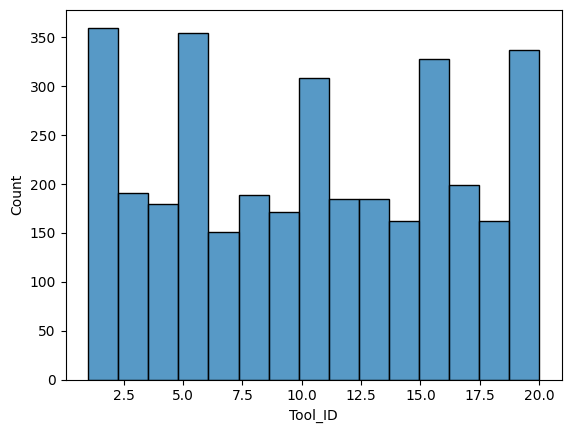

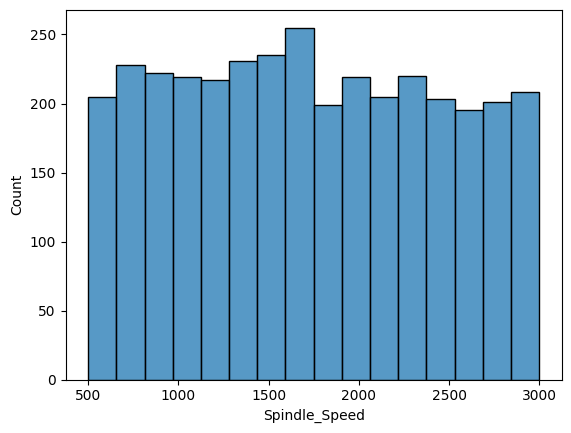

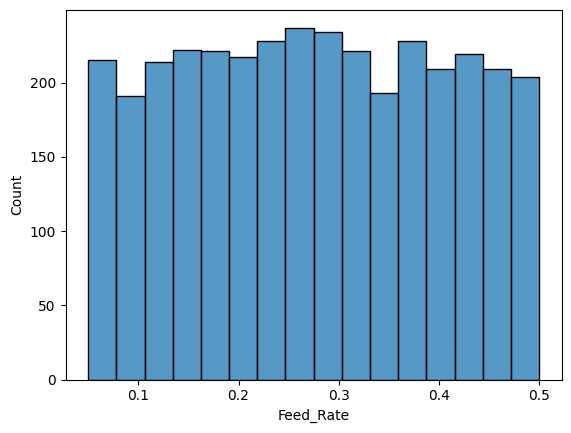

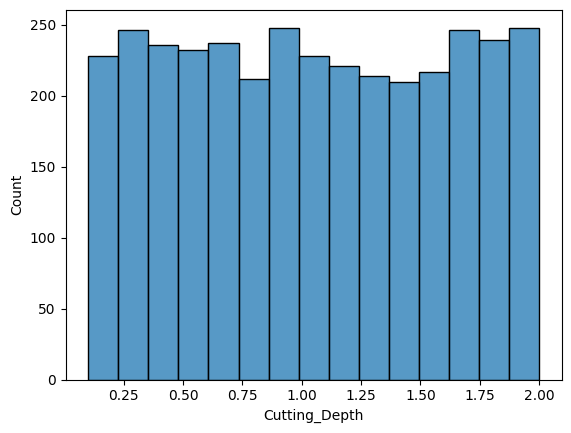

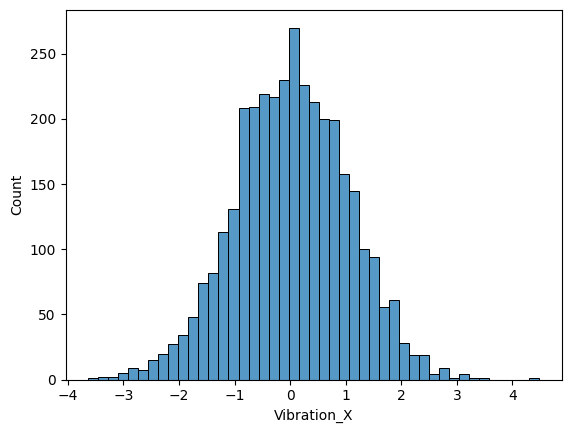

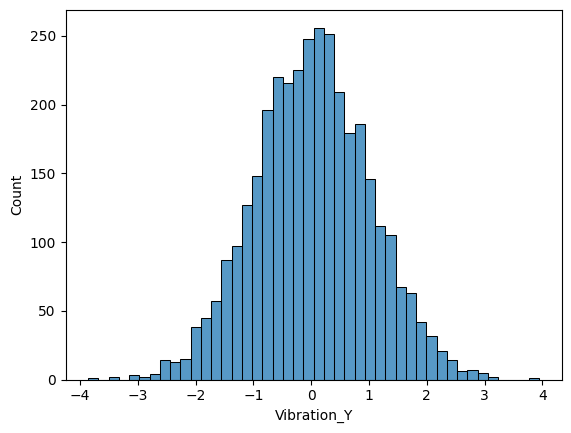

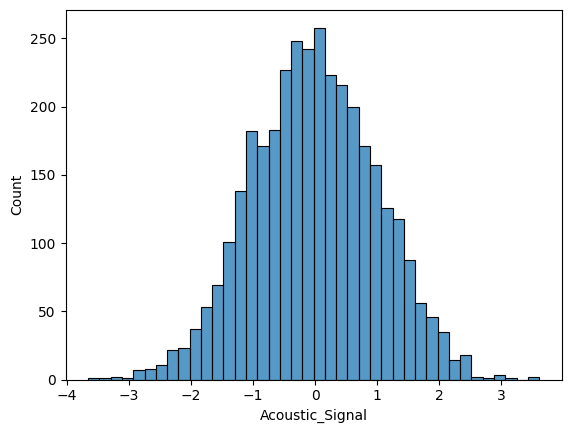

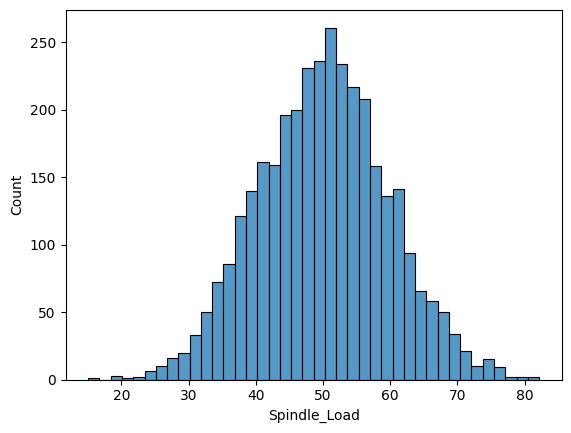

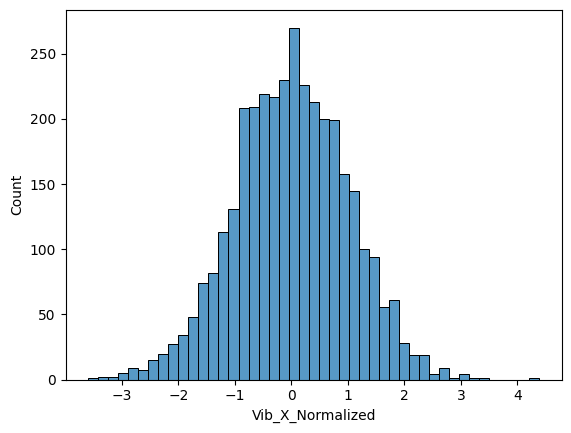

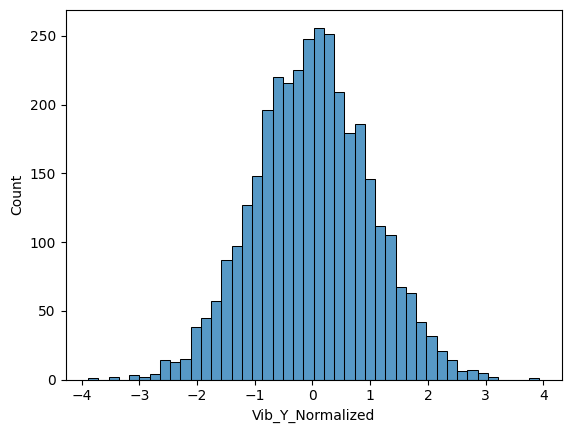

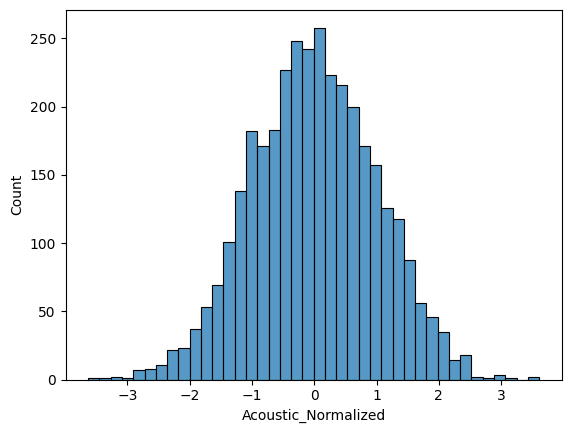

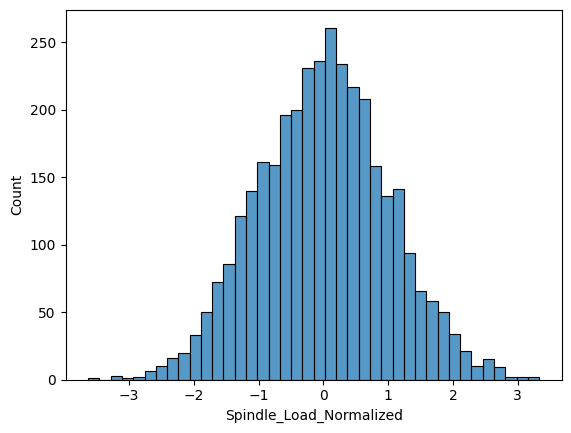

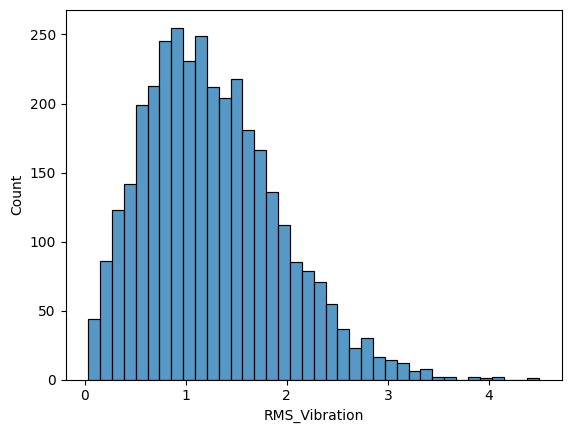

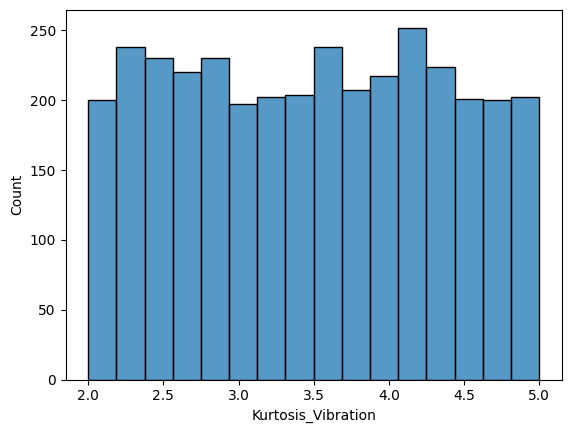

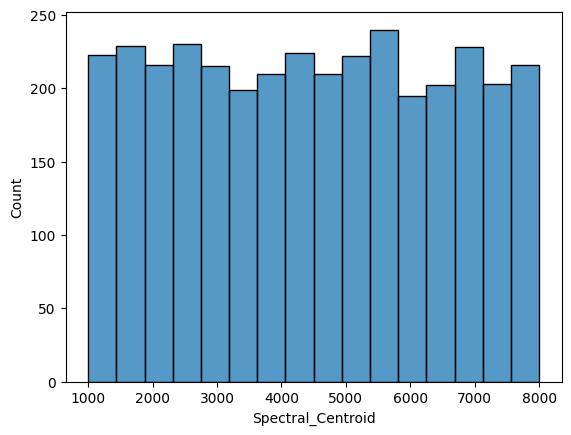

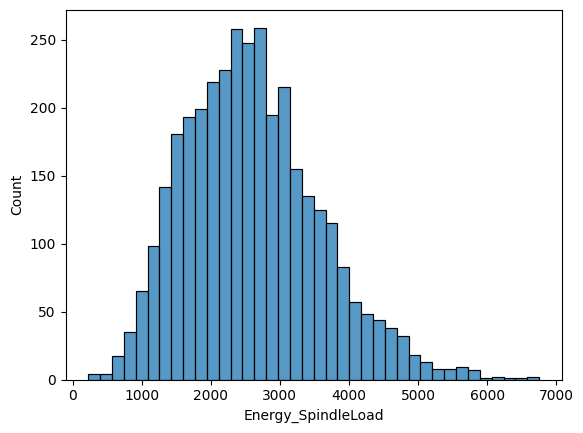

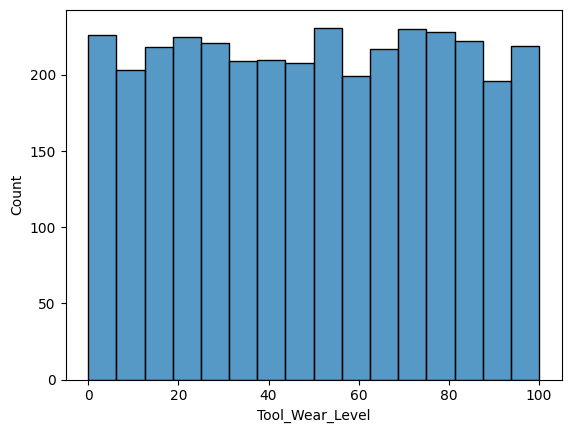

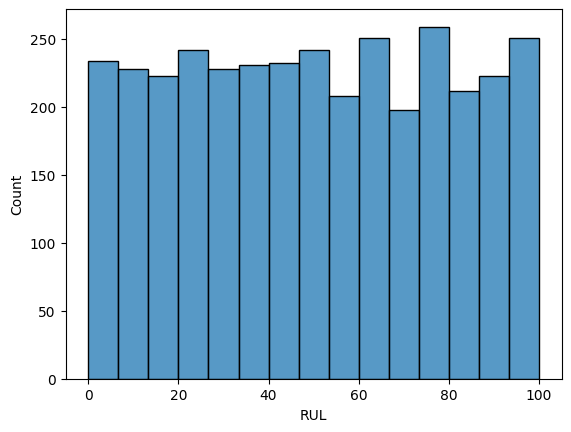

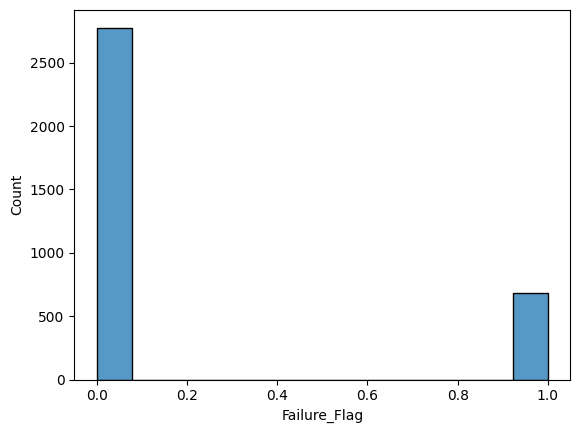

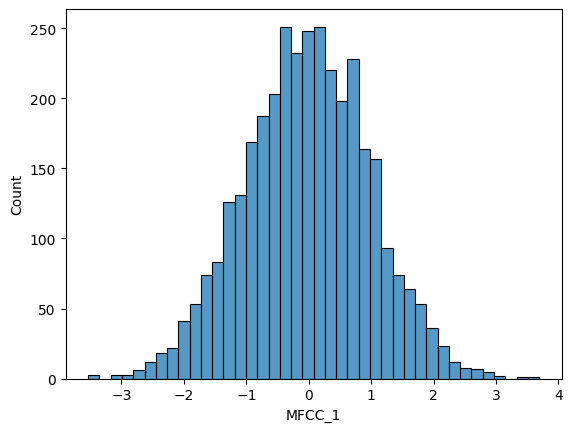

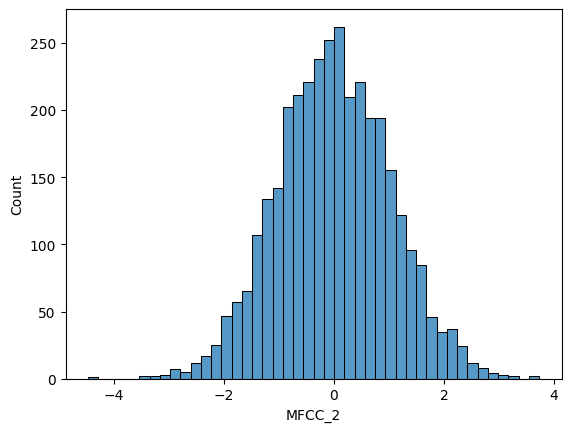

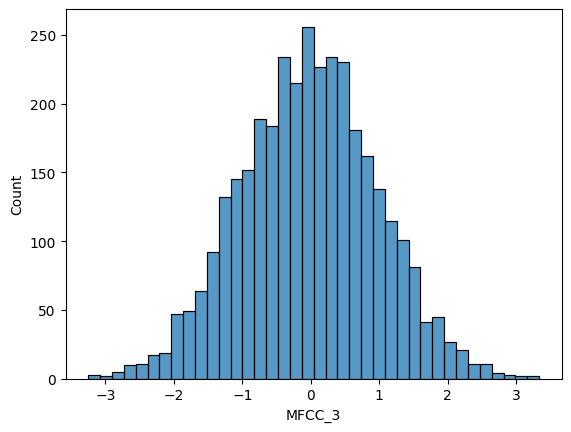

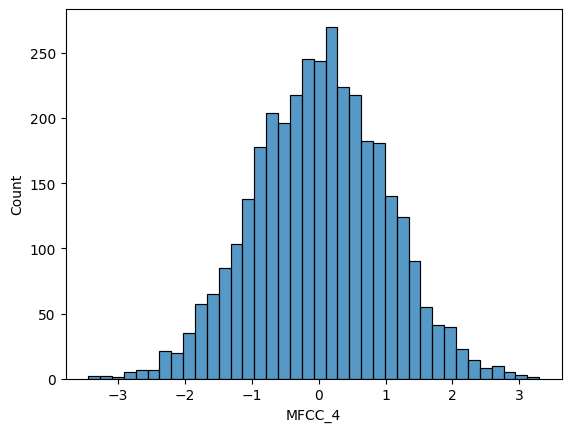

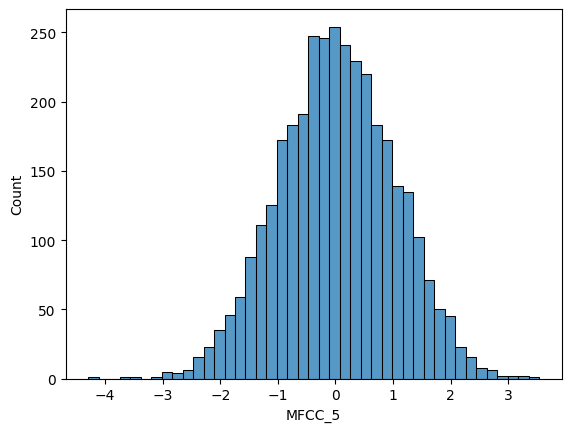

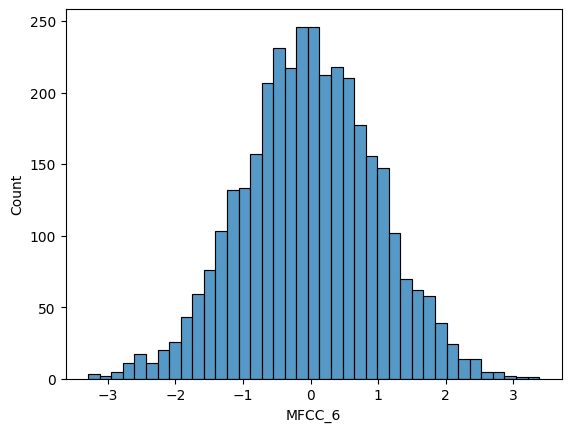

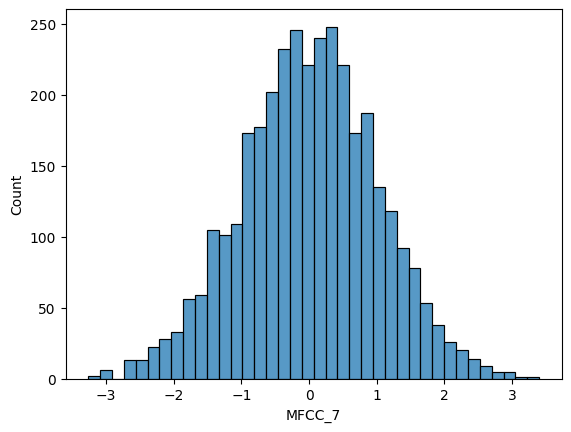

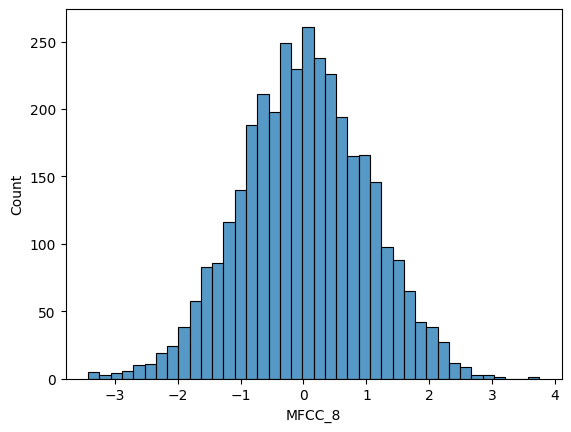

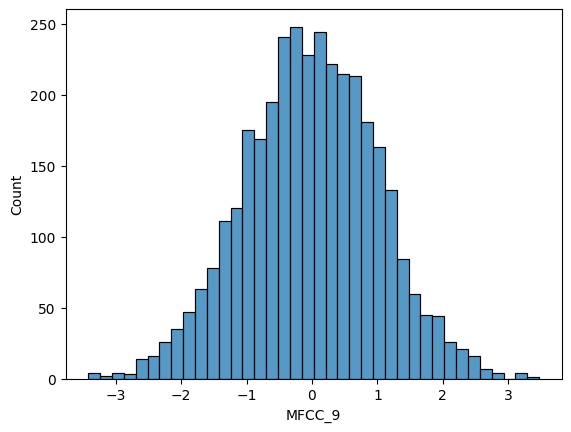

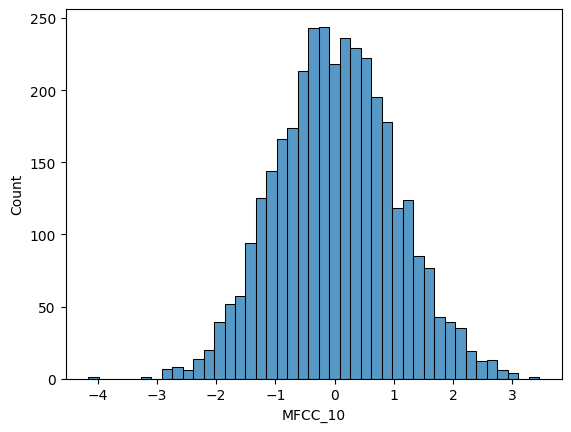

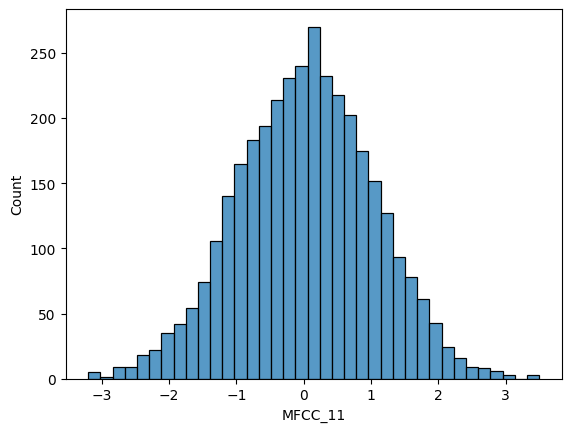

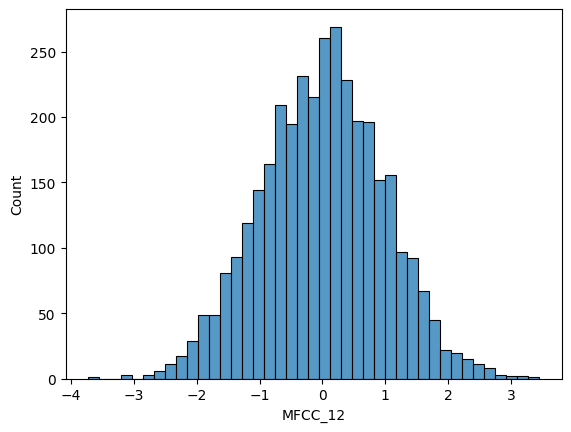

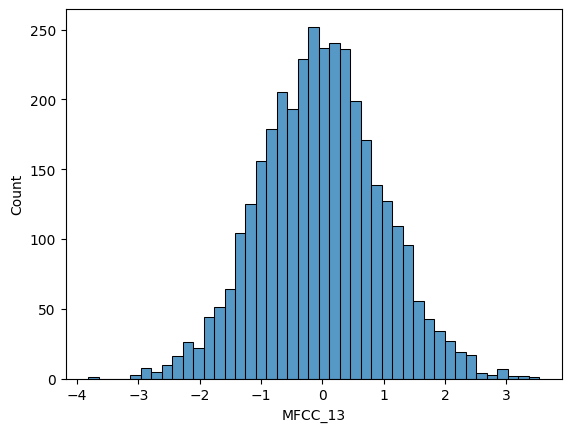

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#histogram
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()


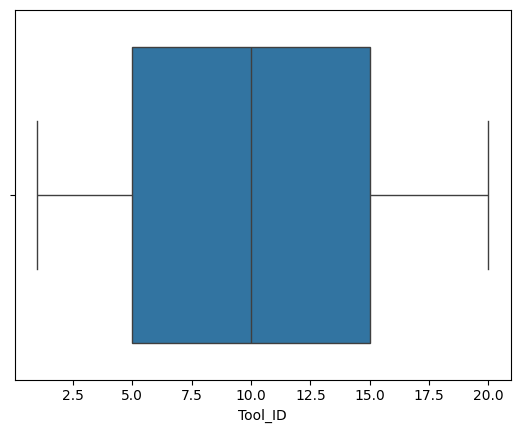

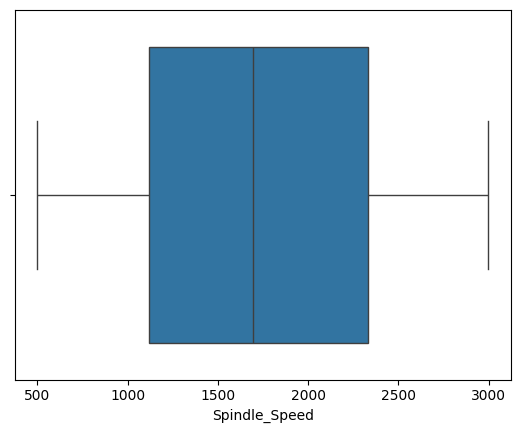

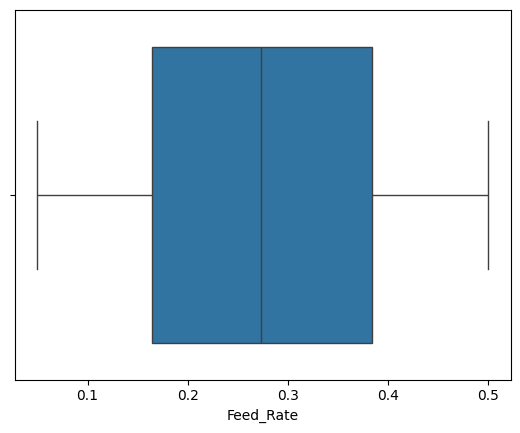

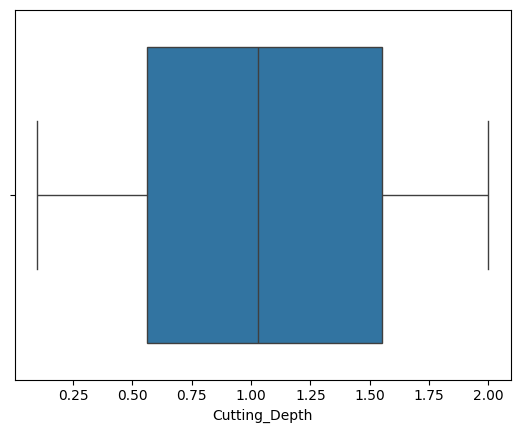

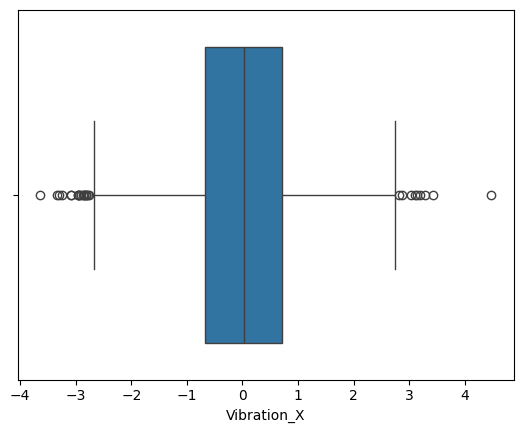

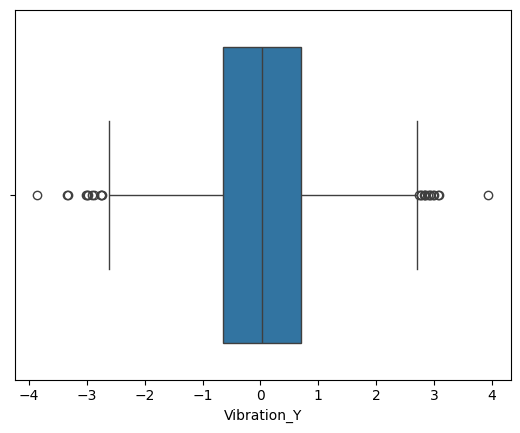

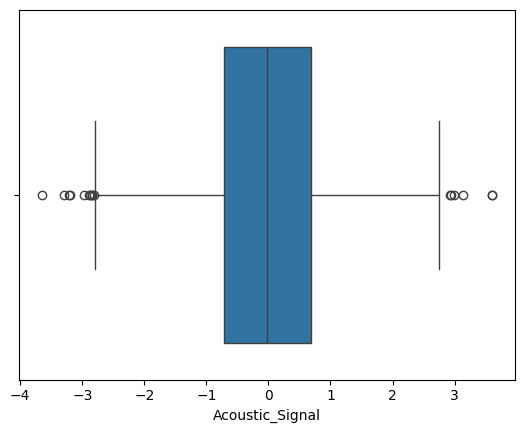

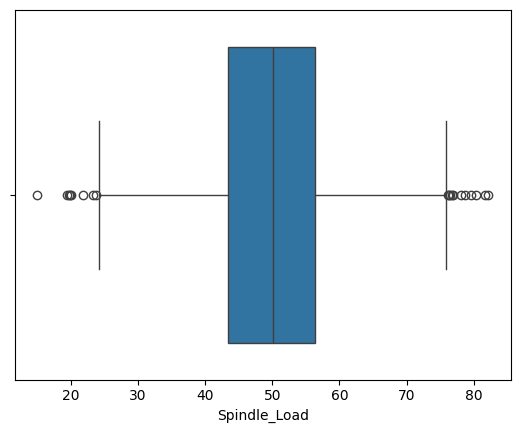

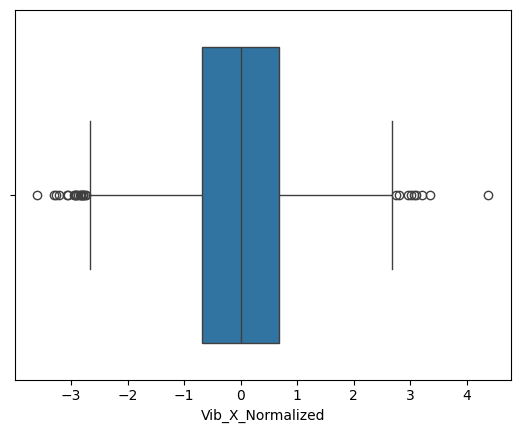

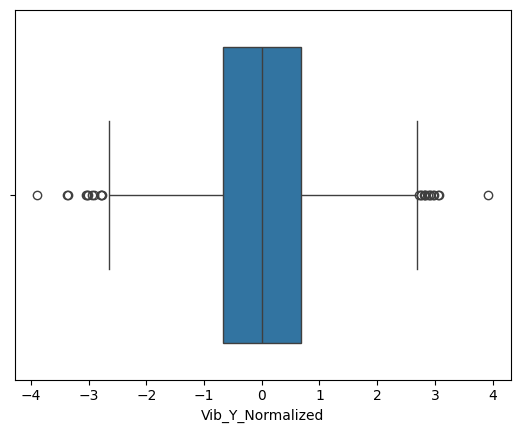

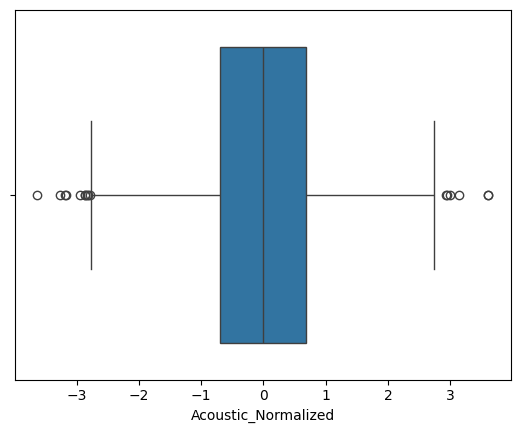

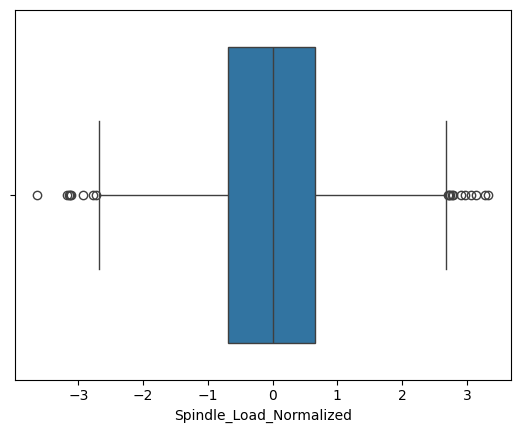

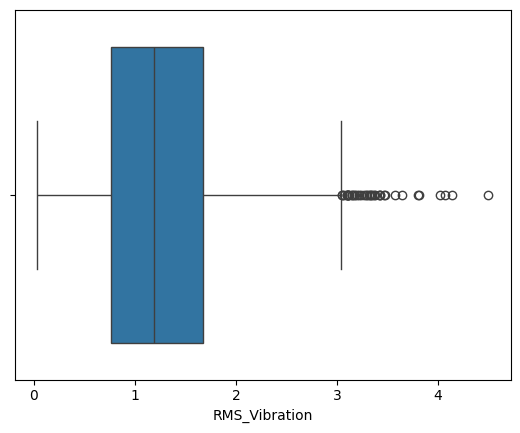

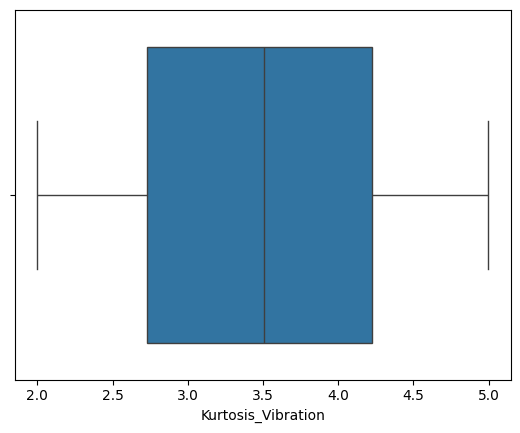

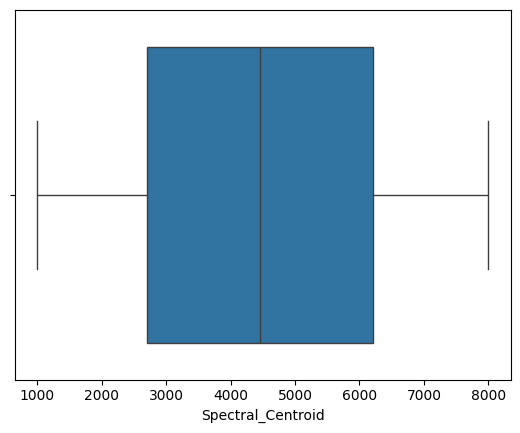

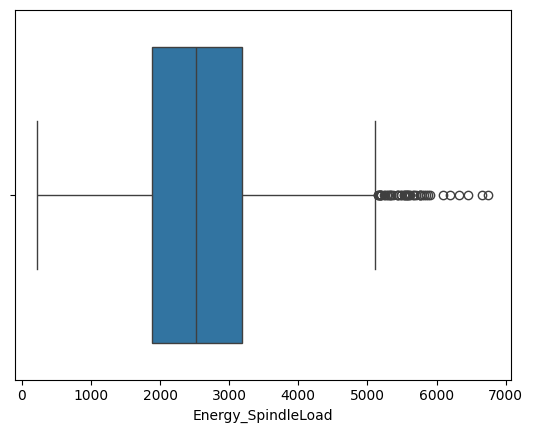

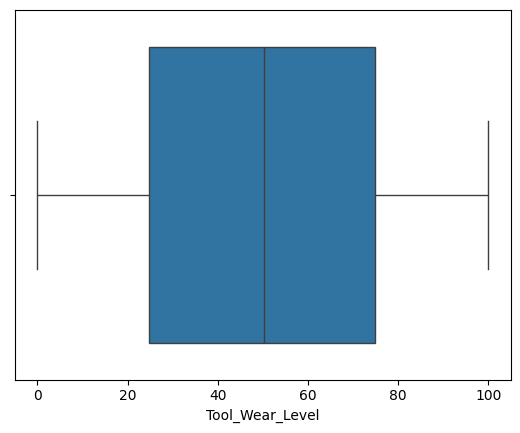

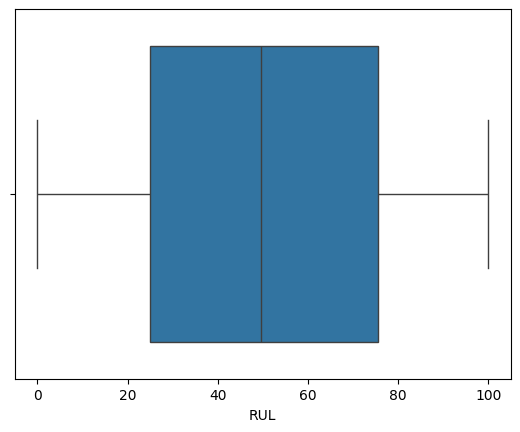

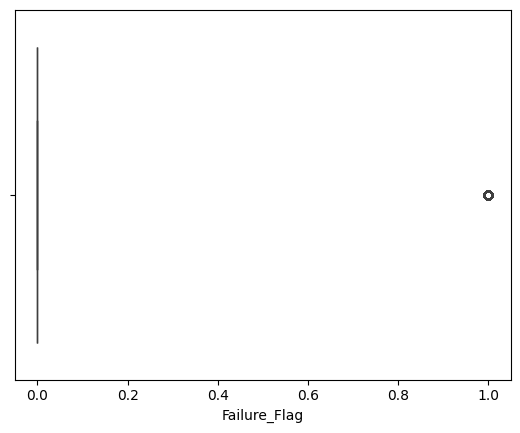

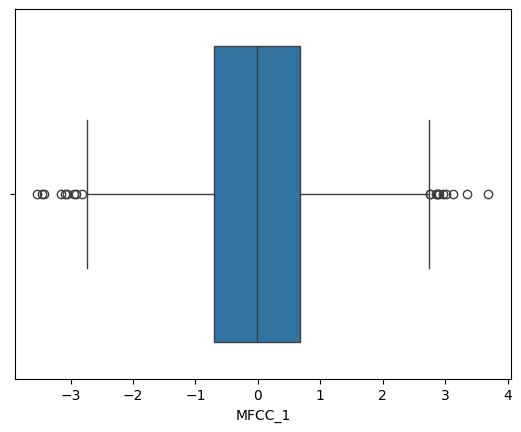

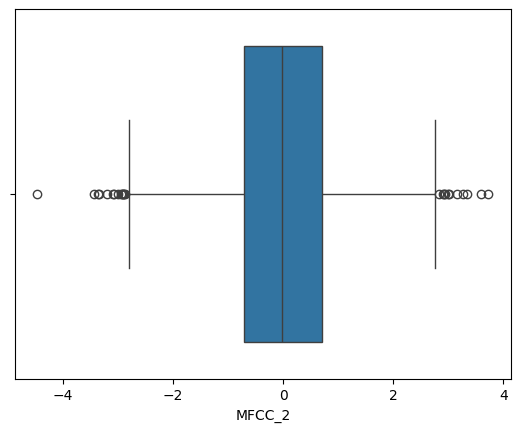

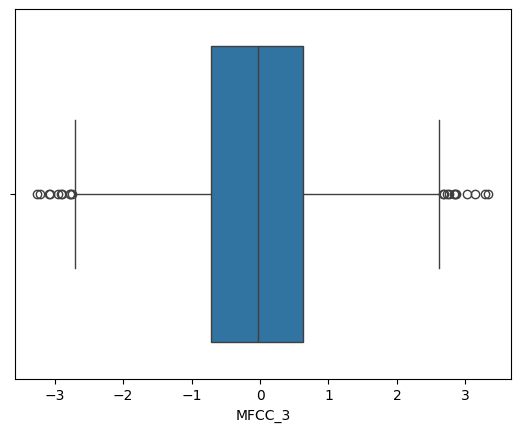

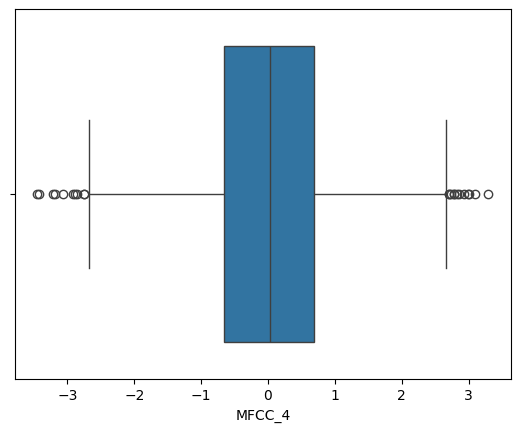

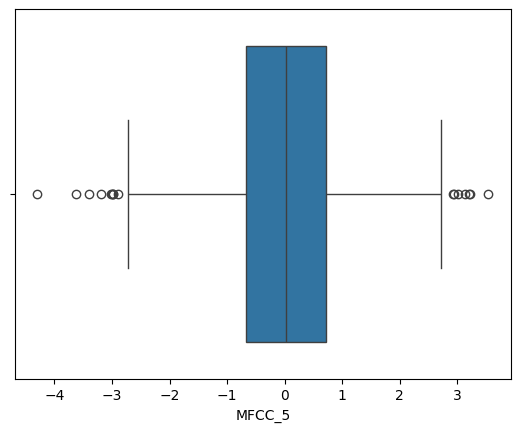

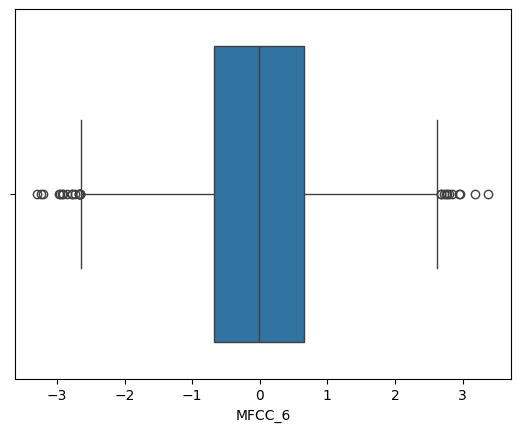

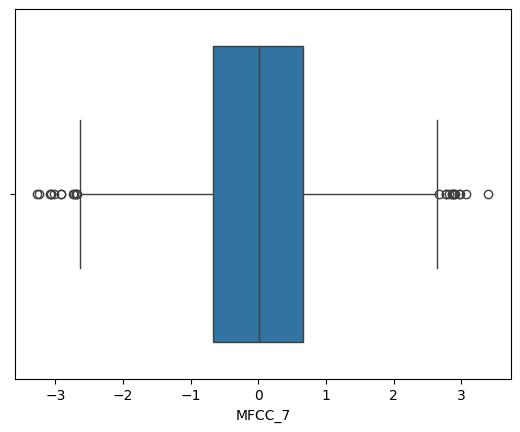

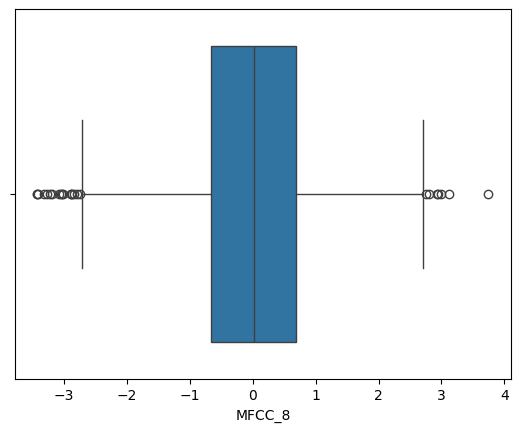

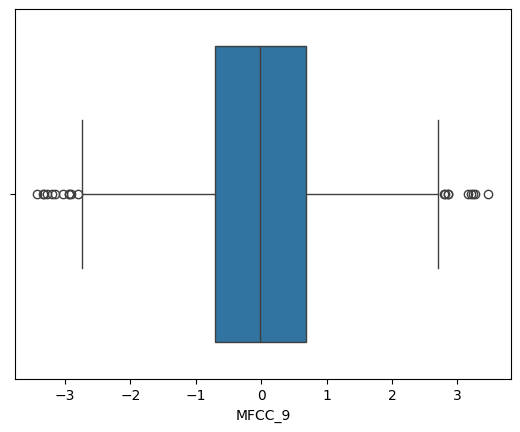

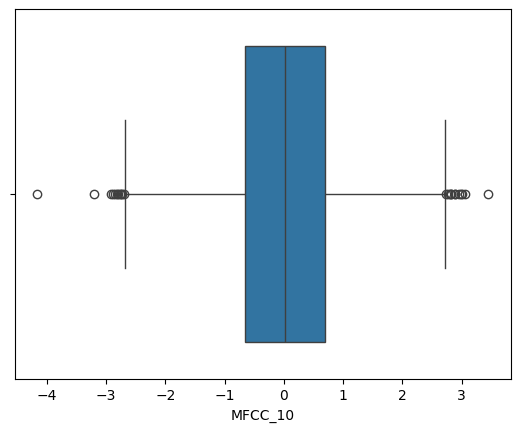

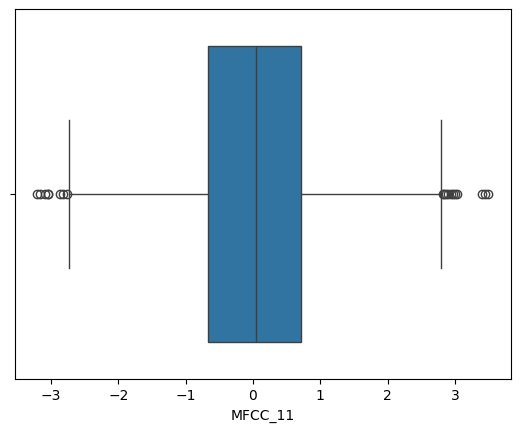

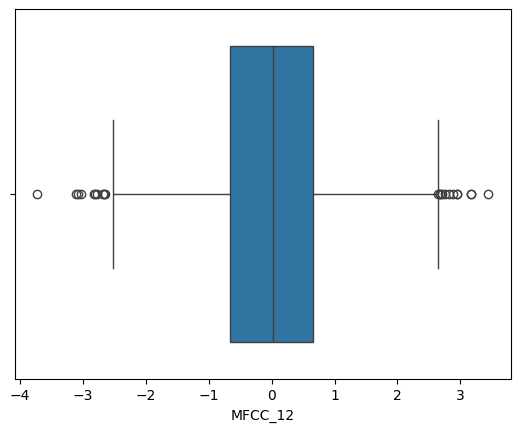

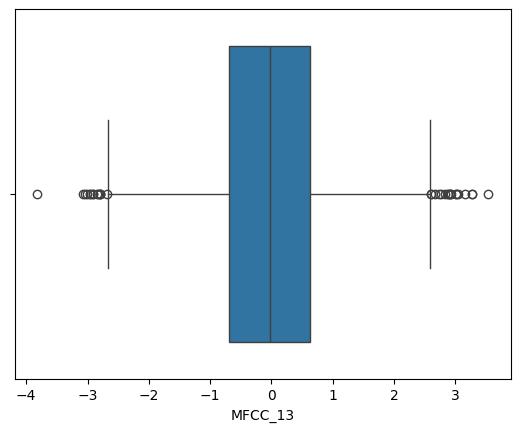

In [8]:
#box plot - outliers
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()


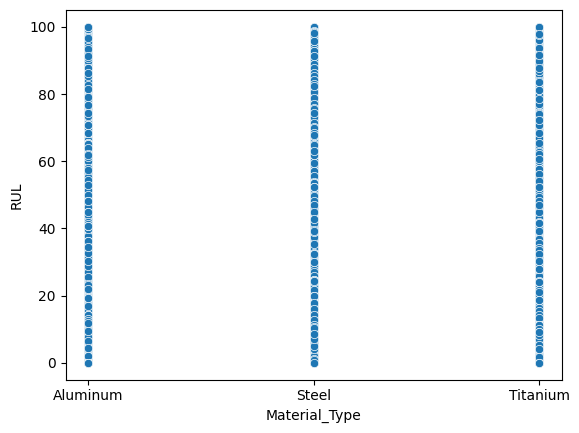

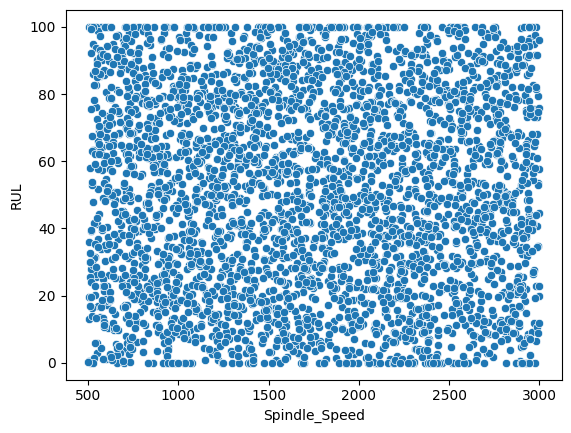

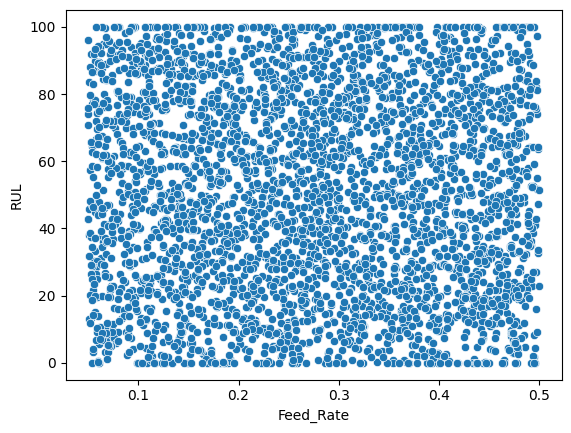

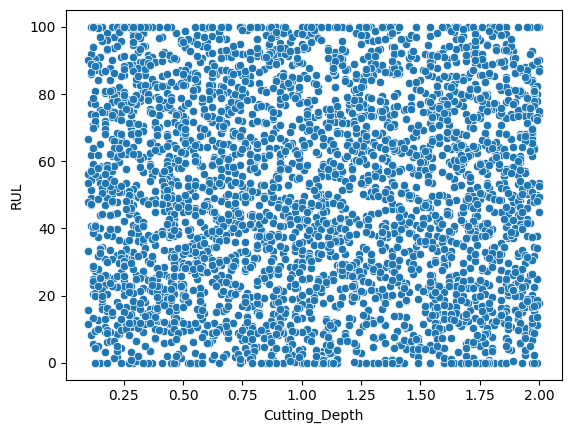

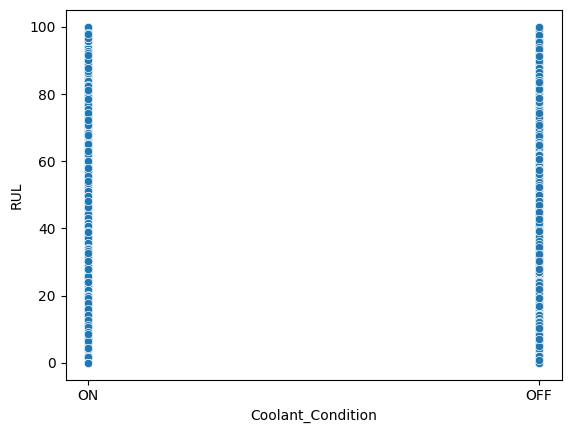

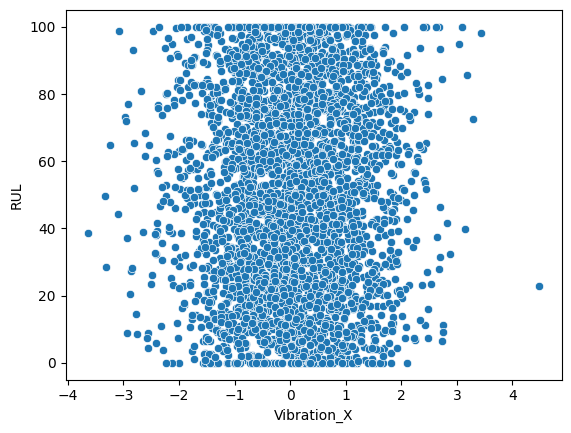

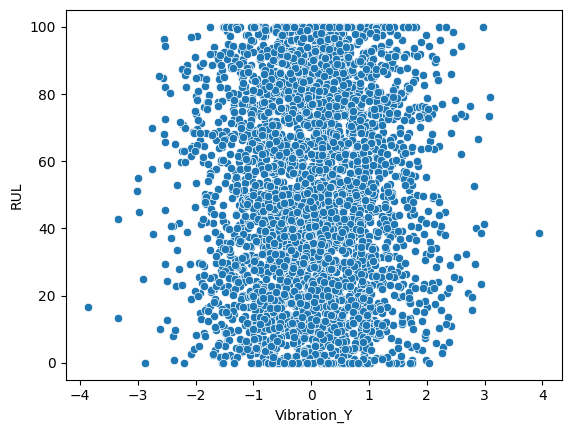

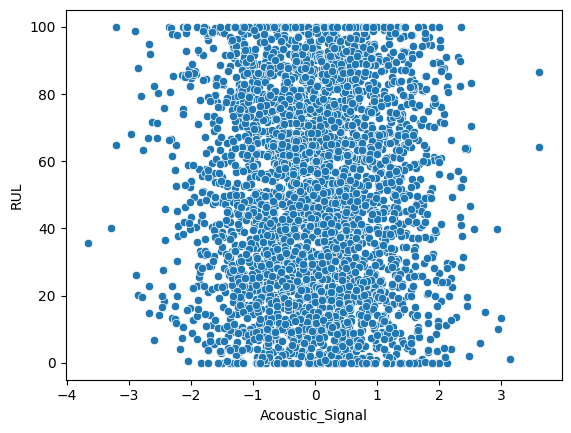

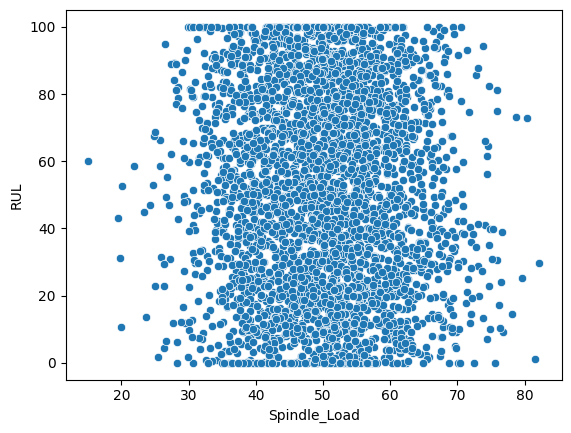

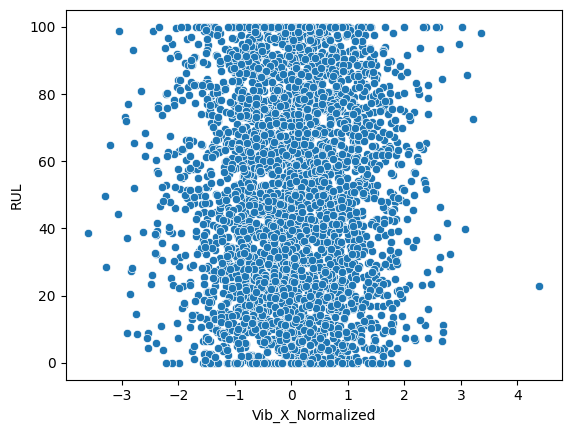

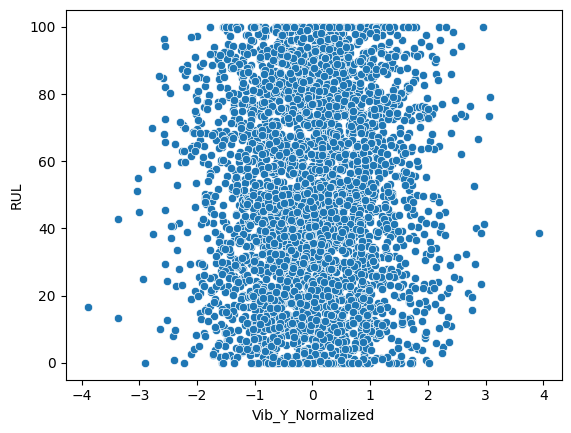

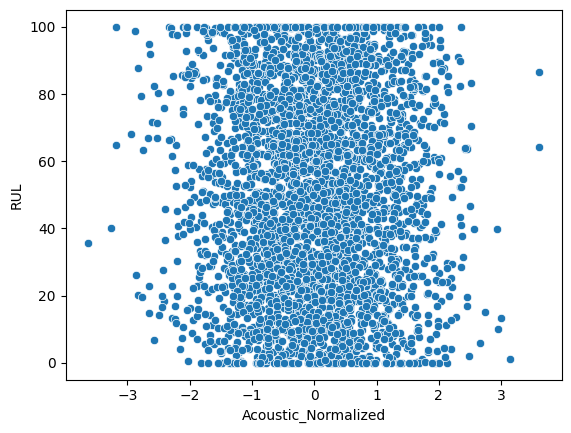

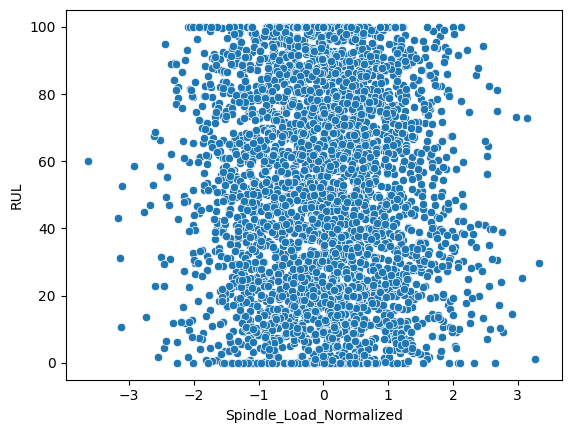

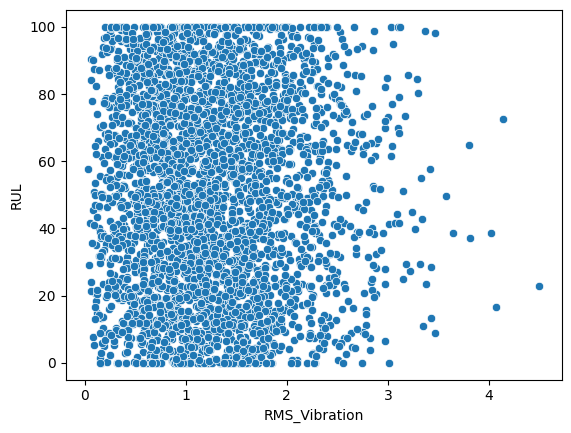

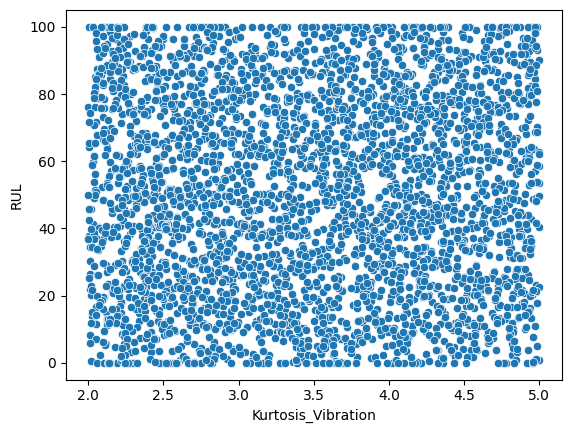

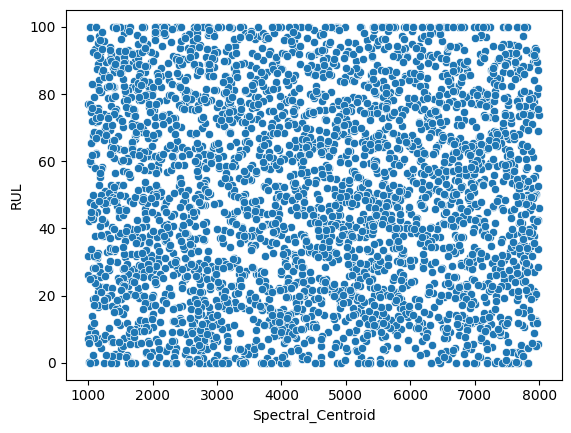

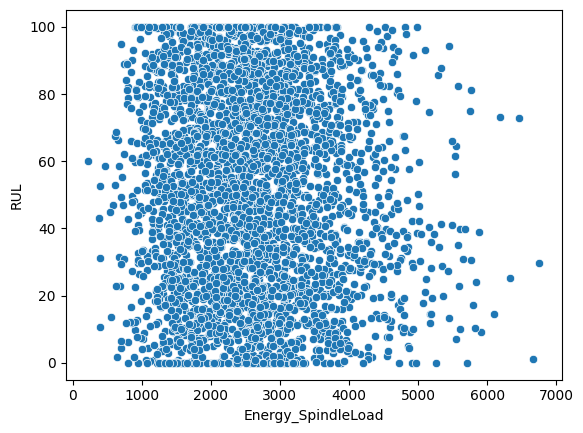

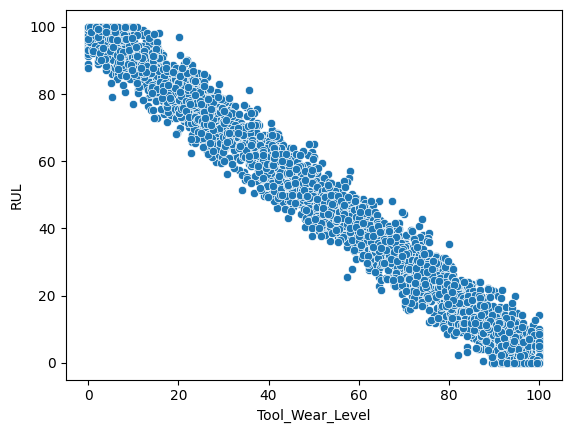

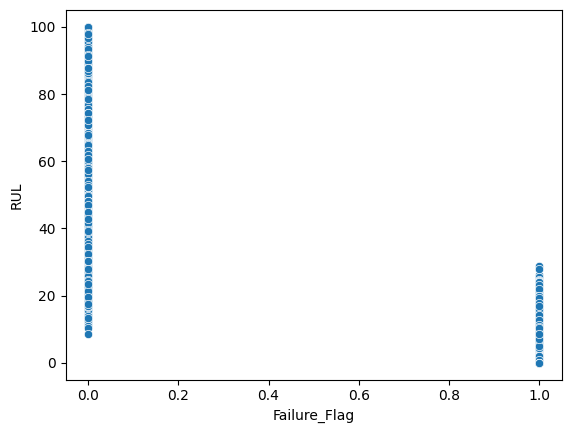

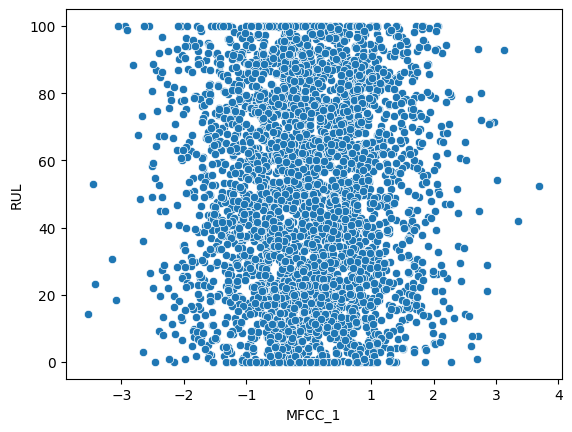

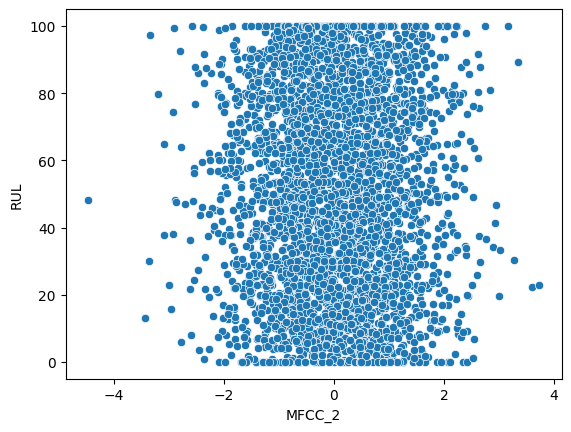

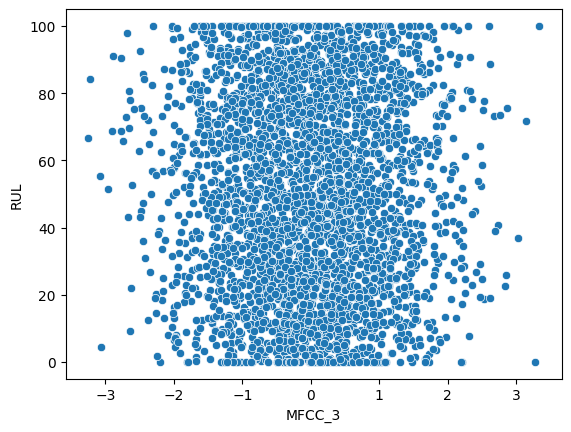

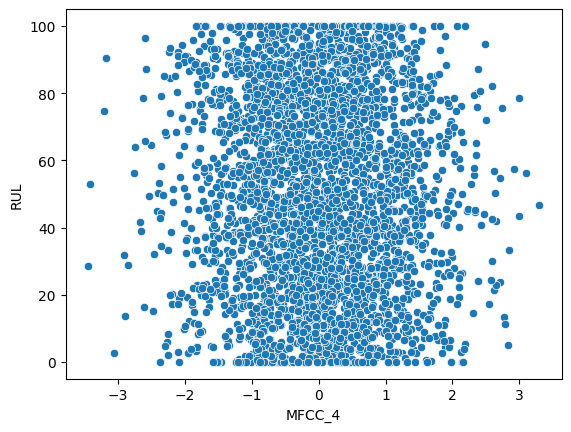

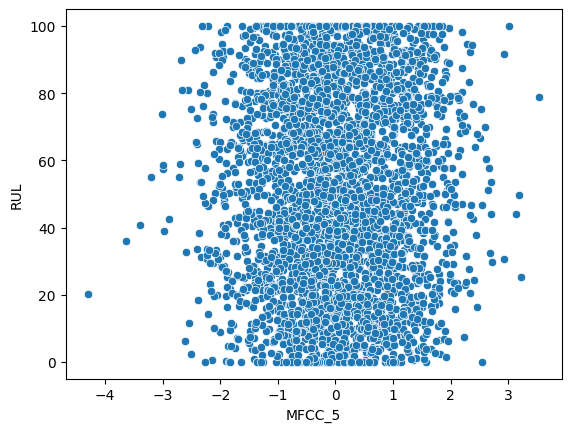

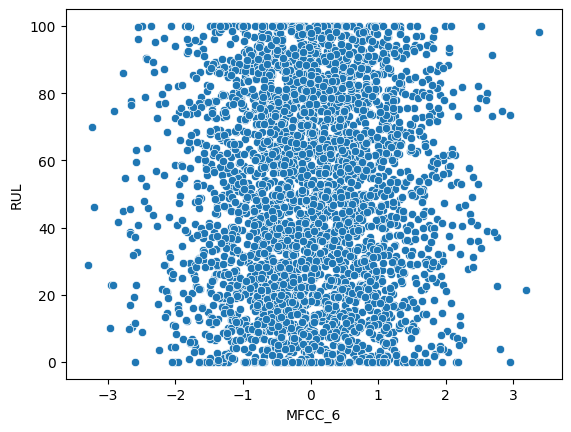

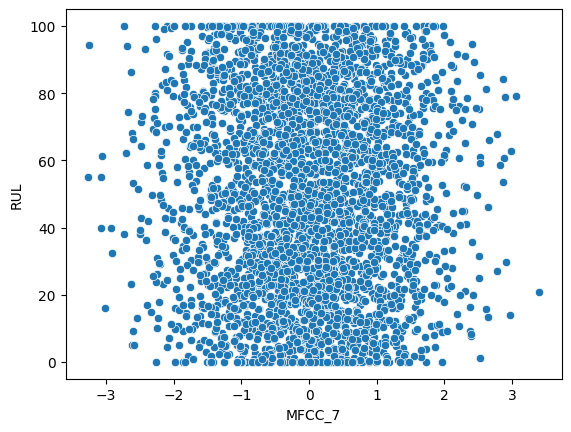

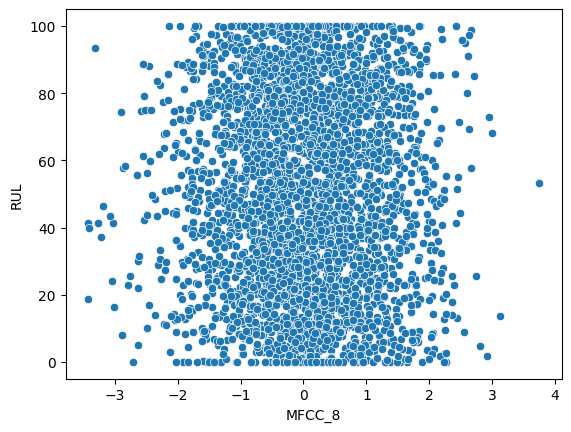

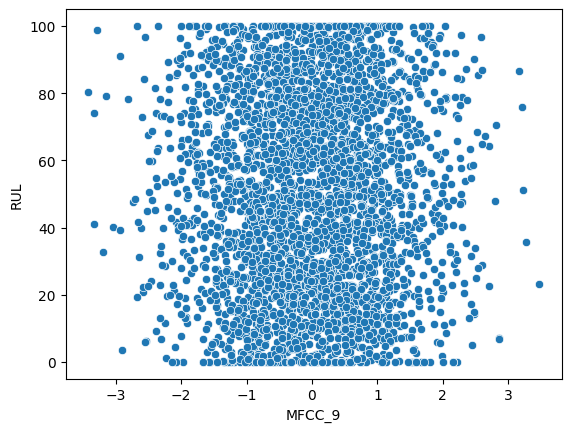

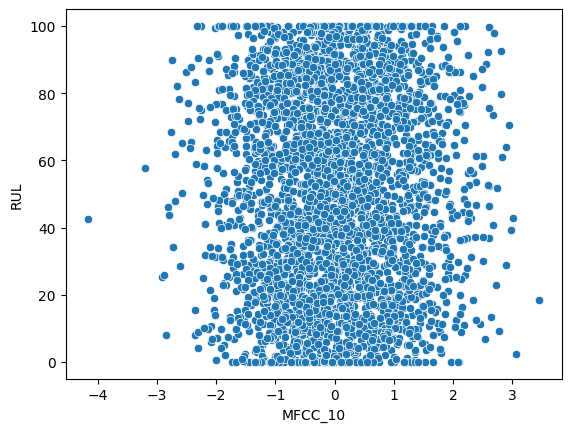

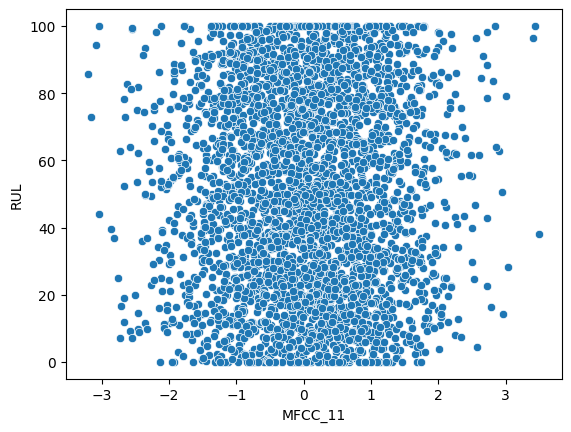

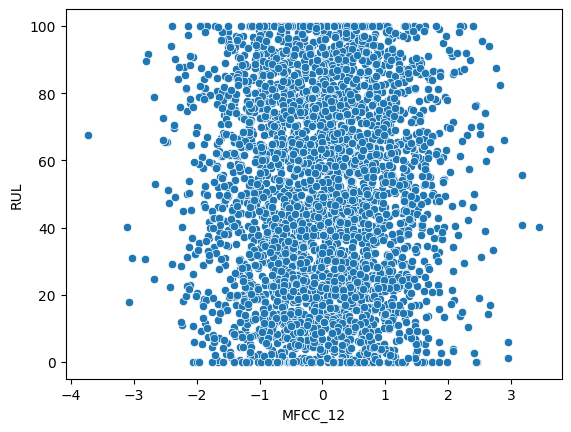

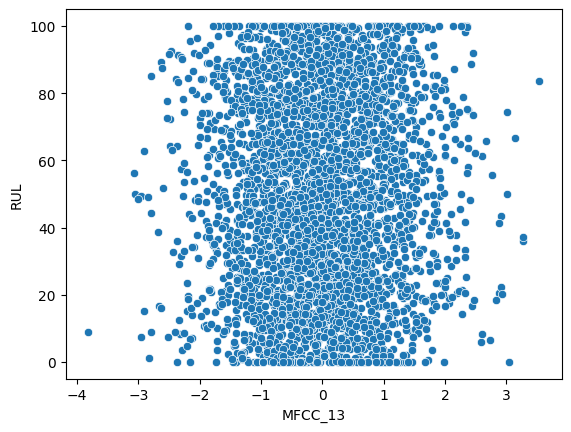

In [9]:
#scatter plt - relationship 
for i in [ 'Material_Type', 'Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Coolant_Condition', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad', 'Tool_Wear_Level', 'Failure_Flag',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13'] :
    sns.scatterplot(data=df,x=i,y='RUL')
    plt.show()


In [10]:
df.columns


Index(['Tool_ID', 'Material_Type', 'Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Coolant_Condition', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad', 'Tool_Wear_Level', 'RUL', 'Failure_Flag',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13'],
      dtype='object')

In [11]:
#correlation matrix
df_corr=df.drop(['Tool_ID','Material_Type','Coolant_Condition'], axis=1)
corr_matrix=df_corr.corr()
print(corr_matrix)

                         Spindle_Speed  Feed_Rate  Cutting_Depth  Vibration_X  \
Spindle_Speed                 1.000000  -0.000479       0.016125     0.000052   
Feed_Rate                    -0.000479   1.000000       0.001593    -0.007196   
Cutting_Depth                 0.016125   0.001593       1.000000    -0.006201   
Vibration_X                   0.000052  -0.007196      -0.006201     1.000000   
Vibration_Y                  -0.009369   0.015184       0.013523    -0.019012   
Acoustic_Signal              -0.044824  -0.018638      -0.010966     0.011281   
Spindle_Load                  0.035312  -0.031728      -0.003883    -0.028474   
Vib_X_Normalized              0.000052  -0.007196      -0.006201     1.000000   
Vib_Y_Normalized             -0.009369   0.015184       0.013523    -0.019012   
Acoustic_Normalized          -0.044824  -0.018638      -0.010966     0.011281   
Spindle_Load_Normalized       0.035312  -0.031728      -0.003883    -0.028474   
RMS_Vibration               

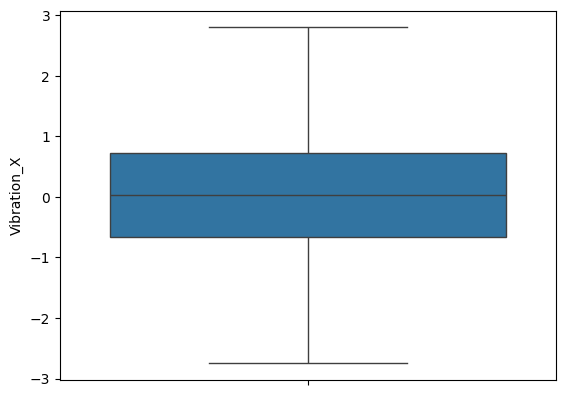

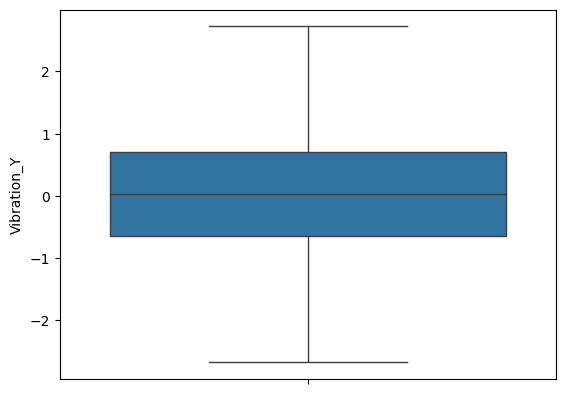

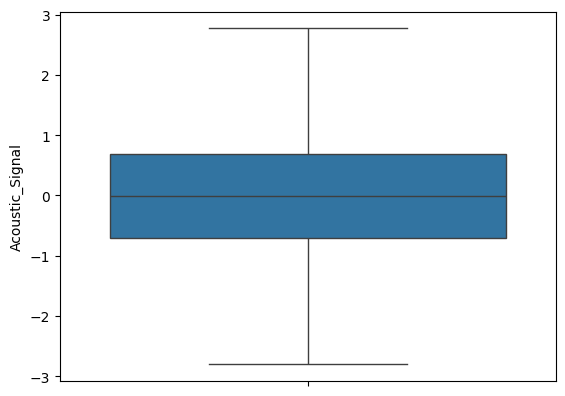

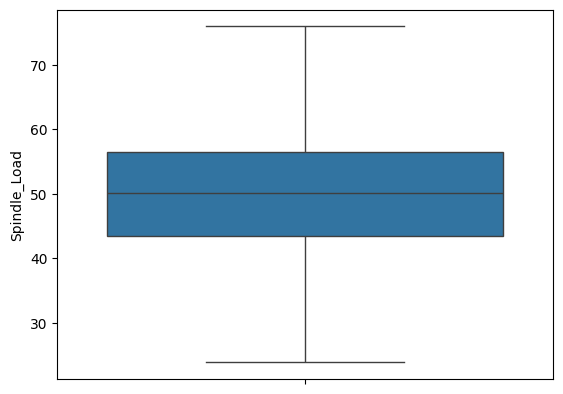

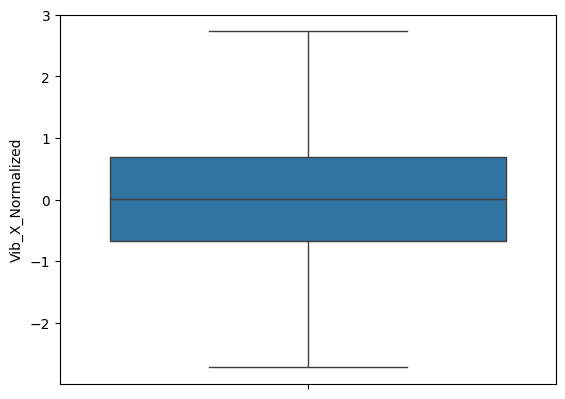

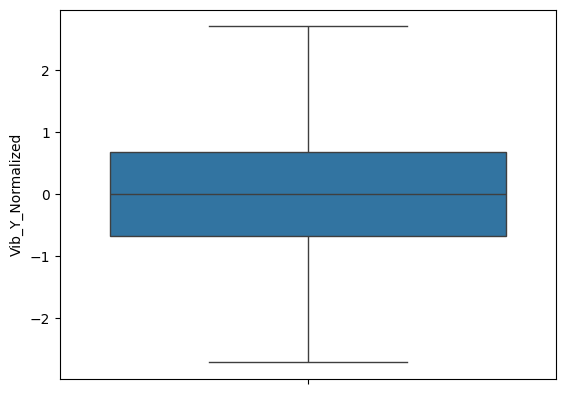

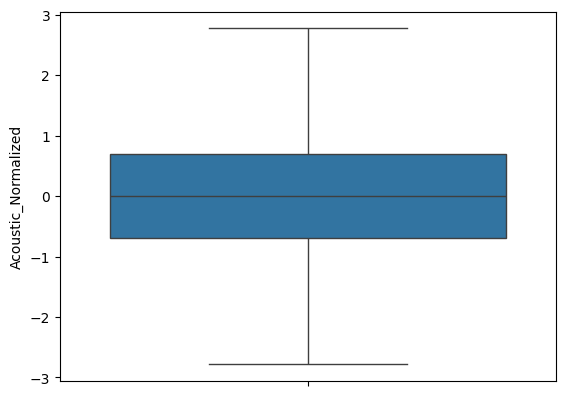

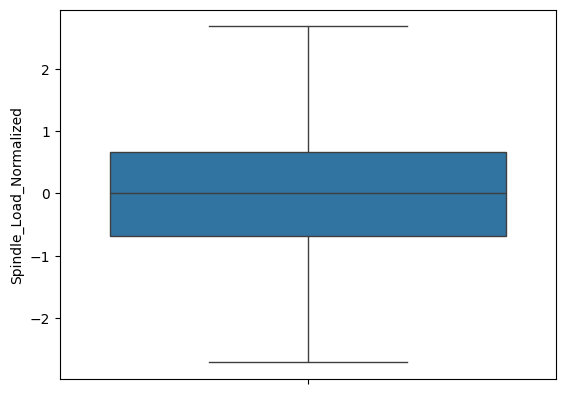

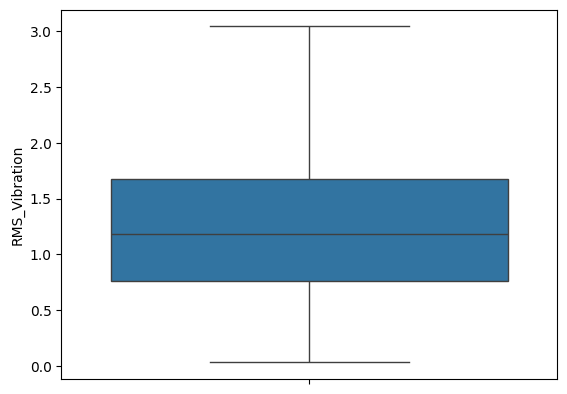

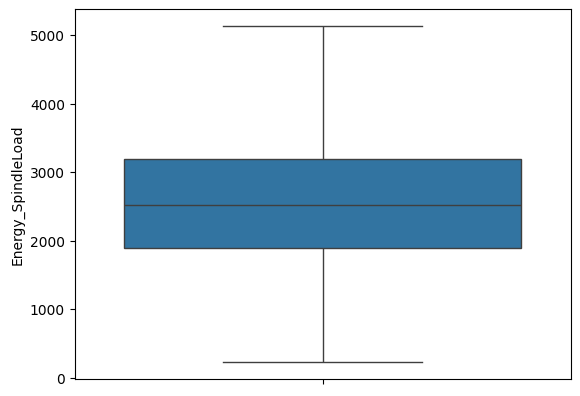

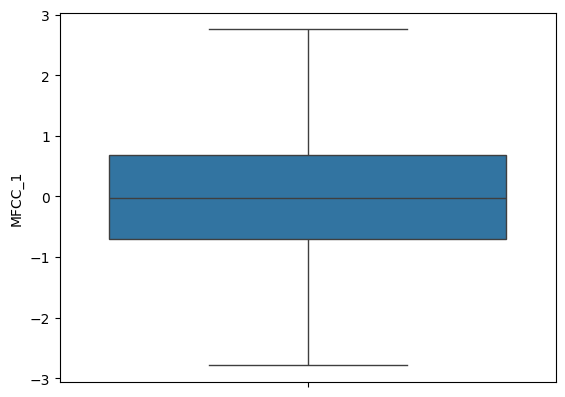

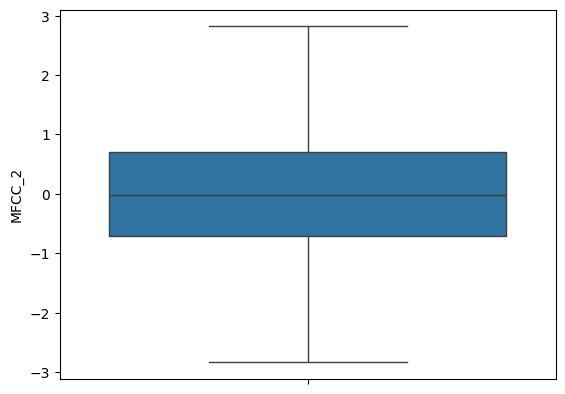

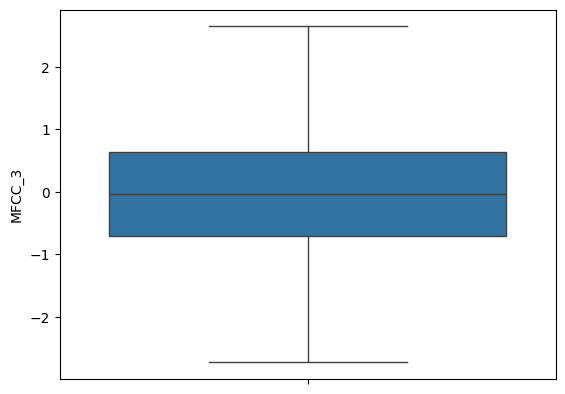

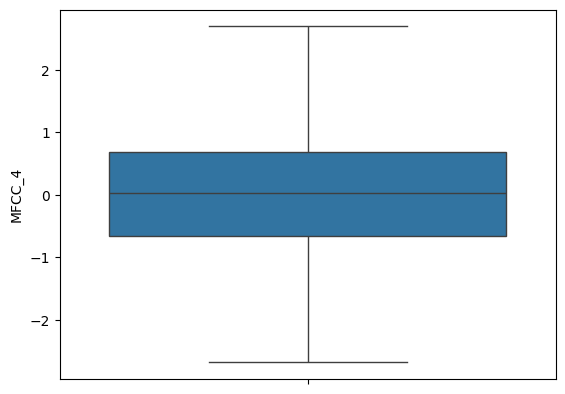

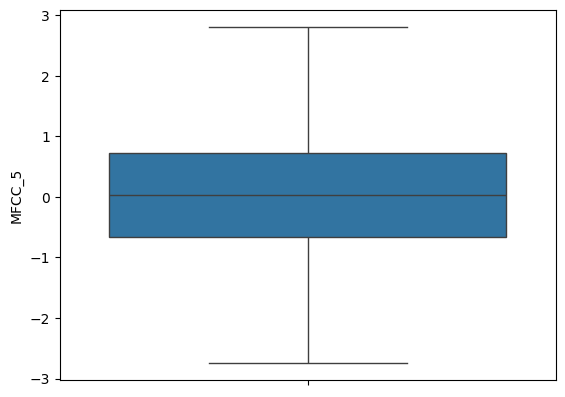

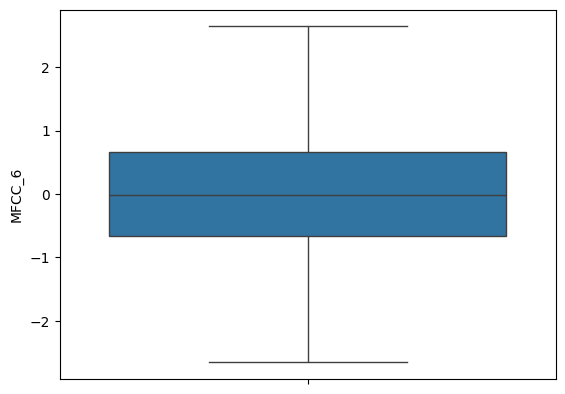

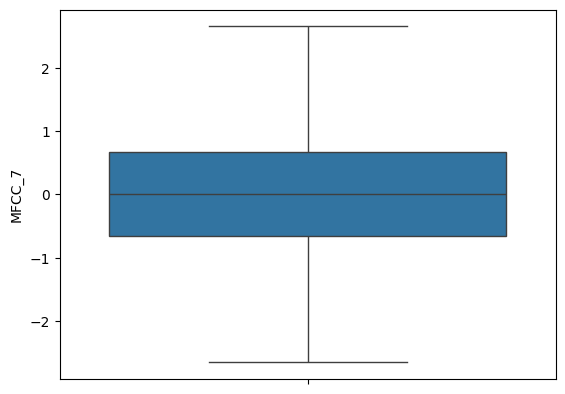

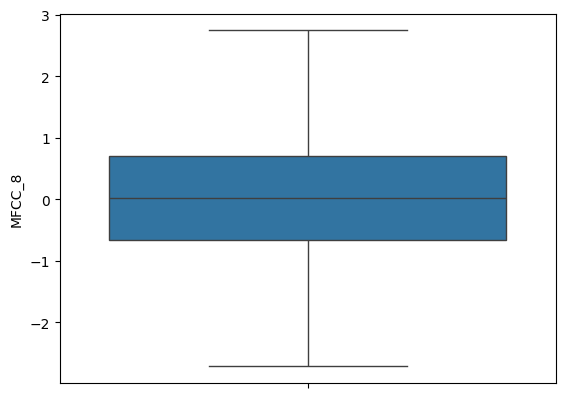

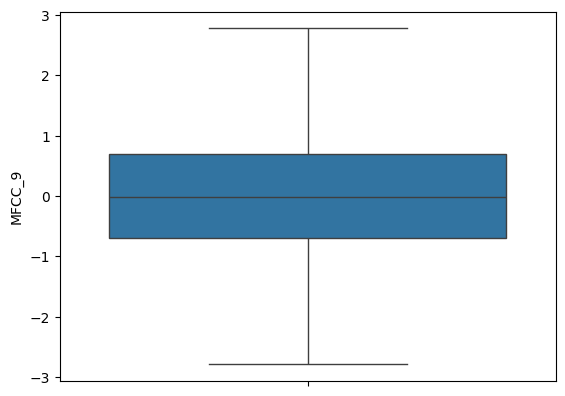

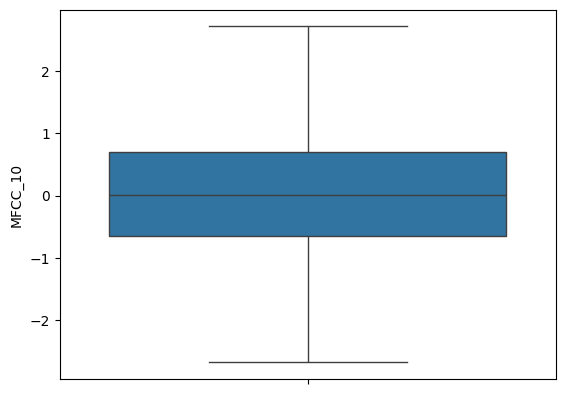

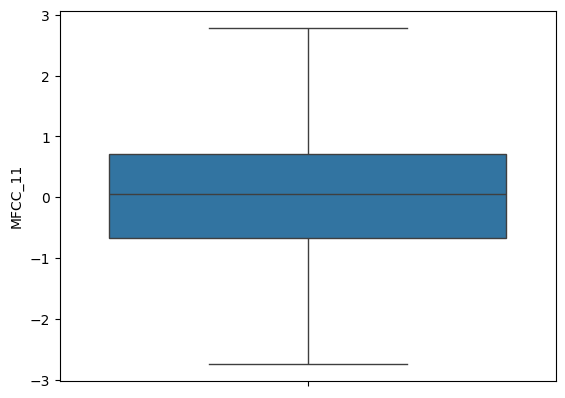

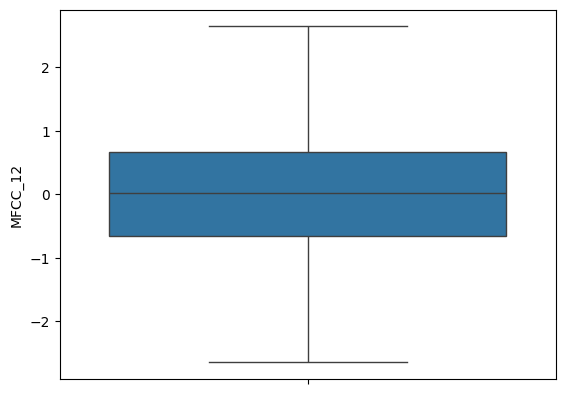

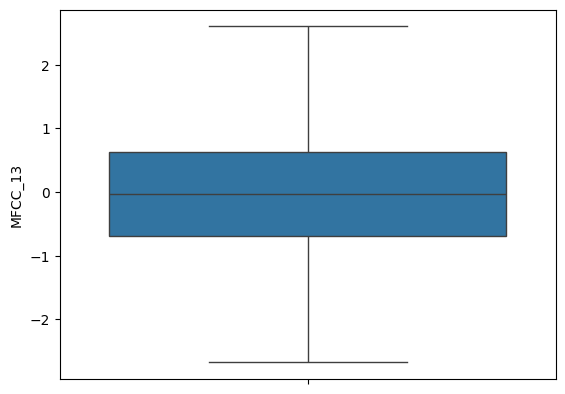

In [12]:
#outliers
def whisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

for i in ['Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration','Energy_SpindleLoad','MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13'] :
    lw,uw=whisker(df[i])
    df[i]=np.where(df[i]<lw,lw,df[i])
    df[i]=np.where(df[i]>uw,uw,df[i])
    sns.boxplot(df[i])
    plt.show()

In [13]:
df.head()

,Tool_ID,Material_Type,Spindle_Speed,Feed_Rate,Cutting_Depth,Coolant_Condition,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,7,Aluminum,2065,0.175,0.89,ON,0.263888,-0.813972,-0.934485,67.416607,...,0.903905,0.238458,0.055227,0.807553,-1.382675,-0.610396,0.169438,0.900103,0.515226,0.048504
1,20,Steel,808,0.478,0.24,ON,-1.454615,-0.609903,1.375179,55.136012,...,-0.842615,-0.271423,0.929104,0.932529,0.453590,-1.150891,0.085663,-0.272520,-0.207385,-0.094697
2,15,Steel,842,0.078,0.29,ON,0.110836,-1.445610,1.873576,42.703536,...,0.317526,2.292517,0.693286,0.139870,1.334206,-1.384250,1.575002,0.666646,-0.545218,-0.126347
3,11,Titanium,935,0.321,0.89,OFF,-1.426464,0.040429,-0.893419,55.830507,...,0.755858,-0.859685,-1.481966,0.983370,-1.963538,-0.907350,-1.498591,1.481619,1.038306,-1.595668
4,8,Aluminum,676,0.076,0.68,ON,0.358334,-0.772673,-0.082838,49.627188,...,1.384203,-0.193839,-0.172788,0.687611,-0.768939,0.687440,2.244171,0.595270,-0.260584,0.276468


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Material_Type_encoded'] = le.fit_transform(df['Material_Type'])
df['Coolant_Condition_encoded'] = le.fit_transform(df['Coolant_Condition'])
df.head()


,Tool_ID,Material_Type,Spindle_Speed,Feed_Rate,Cutting_Depth,Coolant_Condition,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,...,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,Material_Type_encoded,Coolant_Condition_encoded
0,7,Aluminum,2065,0.175,0.89,ON,0.263888,-0.813972,-0.934485,67.416607,...,0.055227,0.807553,-1.382675,-0.610396,0.169438,0.900103,0.515226,0.048504,0,1
1,20,Steel,808,0.478,0.24,ON,-1.454615,-0.609903,1.375179,55.136012,...,0.929104,0.932529,0.453590,-1.150891,0.085663,-0.272520,-0.207385,-0.094697,1,1
2,15,Steel,842,0.078,0.29,ON,0.110836,-1.445610,1.873576,42.703536,...,0.693286,0.139870,1.334206,-1.384250,1.575002,0.666646,-0.545218,-0.126347,1,1
3,11,Titanium,935,0.321,0.89,OFF,-1.426464,0.040429,-0.893419,55.830507,...,-1.481966,0.983370,-1.963538,-0.907350,-1.498591,1.481619,1.038306,-1.595668,2,0
4,8,Aluminum,676,0.076,0.68,ON,0.358334,-0.772673,-0.082838,49.627188,...,-0.172788,0.687611,-0.768939,0.687440,2.244171,0.595270,-0.260584,0.276468,0,1


In [15]:
#normalisation - MinMax scalling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df[['Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad', 'Tool_Wear_Level', 'RUL',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13']])
scaler_val=scaler.transform(df[['Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad', 'Tool_Wear_Level', 'RUL',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13']])


In [16]:
df.columns

Index(['Tool_ID', 'Material_Type', 'Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Coolant_Condition', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad', 'Tool_Wear_Level', 'RUL', 'Failure_Flag',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13',
       'Material_Type_encoded', 'Coolant_Condition_encoded'],
      dtype='object')

In [17]:
#will be needed if lstm is used
Al_df = df[(df['Material_Type_encoded'] == 0)]
Steel_df = df[(df['Material_Type_encoded'] == 1)]
Ti_df=df[(df['Material_Type_encoded'] == 2)]


In [18]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
X=df.drop(['RUL','Material_Type','Coolant_Condition'],axis=1)
Y=df[['RUL']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
#fitting
rand=Pipeline([
    ('scaler',StandardScaler()),
    ('random_forest',RandomForestRegressor(n_estimators=100))
])
rand.fit(X_train,Y_train)
#prediction
pred=rand.predict(X_test)
#metrics
from sklearn.metrics import r2_score
r2= r2_score(Y_test,pred)
print('r2 error : ',r2)

c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2 error :  0.9728249133161133


In [19]:
#k-fold test
from sklearn.model_selection import KFold, cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(rand,X,Y,cv=kf)
print("Accuaracy of each fold : ",score)


c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\s

Accuaracy of each fold :  [0.97118578 0.96997863 0.96942283 0.96973849 0.97053333]


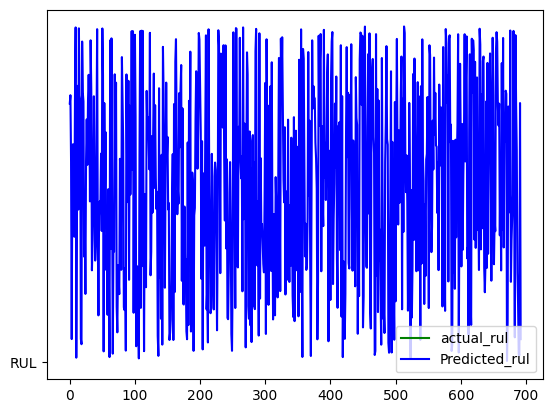

In [20]:
#visualising accuracy 
Y_test=list(Y_test)
plt.plot(Y_test, color="green", label="actual_rul")
plt.plot(pred, color="blue", label="Predicted_rul")
plt.legend()
plt.show()

In [21]:
#svr support vector regression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
X=df.drop(['RUL','Material_Type','Coolant_Condition'],axis=1)
Y=df[['RUL']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel='rbf',C=100,epsilon=0.1))
])

model.fit(X_train,Y_train)
y_pred_svr=model.predict(X_test)

mse_svr= mean_squared_error(Y_test,y_pred_svr)
r2_svr = r2_score(Y_test,y_pred_svr)
print('mean sq error : ',mse_svr)
print(r2_svr)

c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


mean sq error :  61.28971486968172
0.9320104927300505


In [22]:
#k-fold test
from sklearn.model_selection import KFold, cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(model,X,Y,cv=kf)
print("Accuaracy of each fold : ",score)


c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn

Accuaracy of each fold :  [0.93141083 0.94213232 0.93582103 0.93191061 0.93386232]


In [23]:
#Gausian Process Regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,Matern,WhiteKernel
kernel= RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3)
gpr= Pipeline([
    ('scaler',StandardScaler()),
    ('gpr',GaussianProcessRegressor(kernel=kernel,alpha=1e-6,normalize_y=True))
])
gpr.fit(X_train,Y_train)
y_pred_gpr, y_pred_standard_deviation = gpr.predict(X_test,return_std=True)
r2= r2_score(Y_test,y_pred_gpr)
print('r2 error : ',r2)

r2 error :  0.9704497680378725


In [25]:
#k-fold test
from sklearn.model_selection import KFold, cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(gpr,X,Y,cv=kf)
print("Accuaracy of each fold : ",score)

KeyboardInterrupt: 

In [ ]:
#xgboost
import xgboost as xg
xg = Pipeline([
    ('scaler',StandardScaler()),
    ('xgb',xg.XGBRegressor(objective='reg:squarederror',n_estimators=100,random_state=42))
])
xg.fit(X_train,Y_train)
y_pred_xg=xg.predict(X_test)
#r2
r2= r2_score(Y_test,y_pred_xg)
print('r2 error : ',r2)

In [ ]:
#k-fold test
from sklearn.model_selection import KFold, cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(xg,X,Y,cv=kf)
print("Accuaracy of each fold : ",score)

Accuaracy of each fold :  [0.96672666 0.96668559 0.96421438 0.96615231 0.96708757]


In [ ]:
#lstm
#al
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
Al_df['drul'] = Al_df['RUL'].diff().fillna(0)   
drul=Al_df['drul'].astype(float).values.reshape(-1,1)
scaler=MinMaxScaler(feature_range=(0,1))
scaled_df_al=scaler.fit_transform(drul)
x_lstm=[]
y_lstm=[]
for i in range(15,len(scaled_df_al)):
    x_lstm.append(scaled_df_al[i-15:i,0])
    y_lstm.append(scaled_df_al[i,0])
X_lstm_=np.array(x_lstm)
Y_lstm_=np.array(y_lstm)
X_train_L, X_test_L, Y_train_L, Y_test_L = train_test_split(X_lstm_,Y_lstm_,test_size=0.2,shuffle=False)
X_train_L=X_train_L.reshape((X_train_L.shape[0],X_train_L.shape[1],1))
X_test_L=X_test_L.reshape((X_test_L.shape[0],X_test_L.shape[1],1))
lstm_=Sequential()
lstm_.add(LSTM(units=32,input_shape=(X_train_L.shape[1],1)))
lstm_.add(Dropout(0.2))
lstm_.add(Dense(1))

lstm_.compile(optimizer='adam',loss='mean_squared_error')

history=lstm_.fit(X_train_L,Y_train_L,epochs=100,batch_size=30,validation_split=0.1)
y_pred_lstm = lstm_.predict(X_test_L)

y_pred_lstm=scaler.inverse_transform(y_pred_lstm.reshape(-1,1)).flatten()
Y_test_L=scaler.inverse_transform(Y_test_L.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((Y_test_L-y_pred_lstm)**2))
print('rmse',rmse)

r2=r2_score(Y_test_L,y_pred_lstm)
print('r2',r2)

C:\Users\Priyadarshini\AppData\Local\Temp\ipykernel_12608\2419817951.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Al_df['drul'] = Al_df['RUL'].diff().fillna(0)
c:\Users\Priyadarshini\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0911 - val_loss: 0.0471
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0351 - val_loss: 0.0400
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0318 - val_loss: 0.0397
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0322 - val_loss: 0.0394
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0320 - val_loss: 0.0398
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0323 - val_loss: 0.0388
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0305 - val_loss: 0.0388
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0315 - val_loss: 0.0381
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0306 - val_loss: 0.0380
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0306 - val_loss: 0.0375
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0298 - val_loss: 0.0368
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

TypeError: If no scoring is specified, the estimator passed should have a 'score' method. The estimator <Sequential name=sequential, built=True> does not.

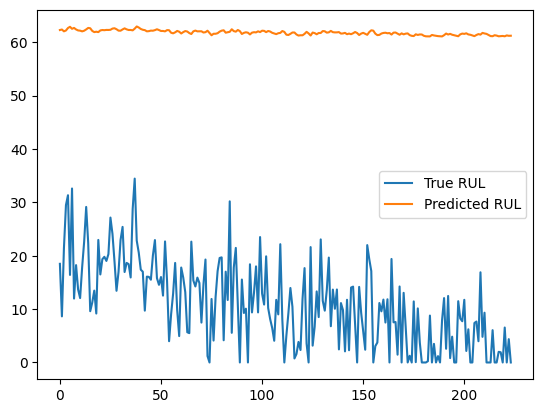

In [ ]:
import matplotlib.pyplot as plt

plt.plot(Y_test_L, label="True RUL")
plt.plot(y_pred_lstm, label="Predicted RUL")
plt.legend()
plt.show()
